# NB4: Rare Genome

**FunPan Aspergillus Pangenome Project**

Pipeline steps:

1. DIAMOND classification of the rare compartment against each species' own core and accessory proteins
2. Restriction of the rare compartment to the DIAMOND No-hit subset
3. Compartment characterisation: protein length, annotation rate, gene-model completeness
4. COG composition of the truly-rare compartment
5. Xenolog screen on GC-outlier truly-rare orthogroups
6. Phylogenetic signal of each phenotype and Mash whole-genome clustering
7. Per-genome rare-gene burden per Mb, with species and kinship corrections

Inputs are read from `NB0_Results/` (phenotype and assembly metadata), `NB1_Results/`
(PAV matrices, orthogroup annotations, kinship and SNP PCs) and the per-species
genome directories. Outputs are saved under `NB4_Results/`.

Analysis functions live in `funpan_utils.py`, `funpan_pangenome.py` and
`funpan_phylo.py`. Sections 2 to 10 each open with a bootstrap cell that sets the
paths, imports those modules and reloads that section's inputs, so any section can
be run on its own from a fresh kernel. Each figure is drawn in the section that
produces its inputs. Edit the path block at the top of a bootstrap cell to point
the notebook at your own directories.

Cached steps have their own switches: `run_diamond` in Section 2, `FORCE_GC` and
`FORCE_BLAST` in Section 6.

---
## Section 1: Configuration

- Paths, species list, display names and the ANI exclusion set
- Reports which inputs are present and creates the output directories before anything runs

In [1]:
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

fphy.nb4_preflight(SPECIES_LIST, SPECIES_ROOT, NB0_RESULTS, NB1_RESULTS,
                   NB4_RESULTS, qc_table=QC_TABLE)

Inputs present: 22/22
  diamond  on PATH
  mash     on PATH
  blastp   on PATH
Output directory: /datadrive/Analysis/NB4_Results


,input,path,exists
0,phenotype table,/datadrive/Analysis/NB0_Results/phenotype_clas...,True
1,assembly metadata,/datadrive/Analysis/NB0_Results/qc_passed_meta...,True
2,fumigatus PAV matrix,/datadrive/Analysis/NB1_Results/fumigatus/fumi...,True
3,fumigatus OG consensus,/datadrive/Analysis/NB1_Results/fumigatus/fumi...,True
4,fumigatus kinship (GRM),/datadrive/Analysis/NB1_Results/fumigatus/fumi...,True
5,fumigatus SNP PCs,/datadrive/Analysis/NB1_Results/fumigatus/fumi...,True
6,fumigatus genome directory,/datadrive/Species/Aspergillus/fumigatus,True
7,flavus PAV matrix,/datadrive/Analysis/NB1_Results/flavus/flavus_...,True
8,flavus OG consensus,/datadrive/Analysis/NB1_Results/flavus/flavus_...,True
9,flavus kinship (GRM),/datadrive/Analysis/NB1_Results/flavus/flavus_...,True


### 1.1 Phenotype labels

- Phenotype table from NB0, one row per genome

In [2]:
pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')
print(pheno_df.groupby('Species')['Phenotype'].value_counts().to_string())

Phenotype labels: 206 genomes
Species       Phenotype        
A. flavus     Human-pathogenic     43
              Plant-pathogenic     19
              Environmental         4
              Industrial-trait      2
              Animal-pathogenic     1
A. fumigatus  Environmental        48
              Human-pathogenic     37
A. niger      Industrial-trait     12
              Environmental         6
              Human-pathogenic      1
A. oryzae     Industrial-trait     32
              Environmental         1


### 1.2 Pangenome matrices and annotations

- PAV matrix and orthogroup consensus annotations per species from NB1
- Core and rare frequency thresholds are recomputed from the filtered PAV by the S-curve method
- Orthogroups carried only by excluded genomes are dropped

In [3]:
species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)


=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3


---
## Section 2: DIAMOND Classification of the Rare Compartment

- The longest representative protein of each rare orthogroup is aligned against the species' own core and accessory pool
- Each rare orthogroup is assigned one of four classes:

| Class | Criterion |
|---|---|
| Full-length homolog | at least 30% identity and at least 80% query and subject coverage |
| Fragment of longer gene | high subject coverage, low query coverage |
| No significant similarity | alignment below threshold |
| No hit | no alignment to core or accessory |

- Requires the `diamond` binary on PATH
- Results are cached per species in `NB4_Results/{species}/diamond_rare_classification.tsv`

In [4]:
# Standalone bootstrap: run this cell to use Section 2 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')

species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)

Phenotype labels: 206 genomes

=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3


In [5]:
# DIAMOND runs on first use and is cached per species; set run_diamond=False to skip it.
_inputs = fphy.prepare_rare_characterisation_inputs(
    SPECIES_LIST, species_data, SPECIES_CONFIG, SPECIES_DISPLAY,
    BASE_PATH, RESULTS_DIR, run_diamond=True
)
SPECIES_DEEP    = _inputs['species_deep']
length_data     = _inputs['length_data']
rates_df        = _inputs['rates_df']
diamond_results = _inputs['diamond_results']

Species with >50 rare OGs (deep characterisation): ['fumigatus', 'flavus', 'niger', 'oryzae']
  fumigatus: 10881 OGs with length data
  flavus: 14450 OGs with length data
  niger: 12453 OGs with length data
  oryzae: 14279 OGs with length data
Annotation rates table: (60, 6)
A. fumigatus: loaded cached DIAMOND results (771 rare OGs), No hit: 291, Fragment of longer gene: 255, No significant similarity: 122, Full-length homolog: 103
A. flavus: loaded cached DIAMOND results (1159 rare OGs), Fragment of longer gene: 400, No hit: 391, No significant similarity: 210, Full-length homolog: 158
A. niger: loaded cached DIAMOND results (576 rare OGs), No hit: 276, Fragment of longer gene: 118, No significant similarity: 100, Full-length homolog: 82
A. oryzae: loaded cached DIAMOND results (552 rare OGs), Fragment of longer gene: 226, No hit: 156, No significant similarity: 94, Full-length homolog: 76


### 2.1 Classification figure

- One pie per species over the four classes
- Reads `NB4_Results/diamond_classification_summary.csv`
- Saved to `NB4_Results/diamond_classification_pies.png`

Saved -> /datadrive/Analysis/NB4_Results/diamond_classification_pies.png  


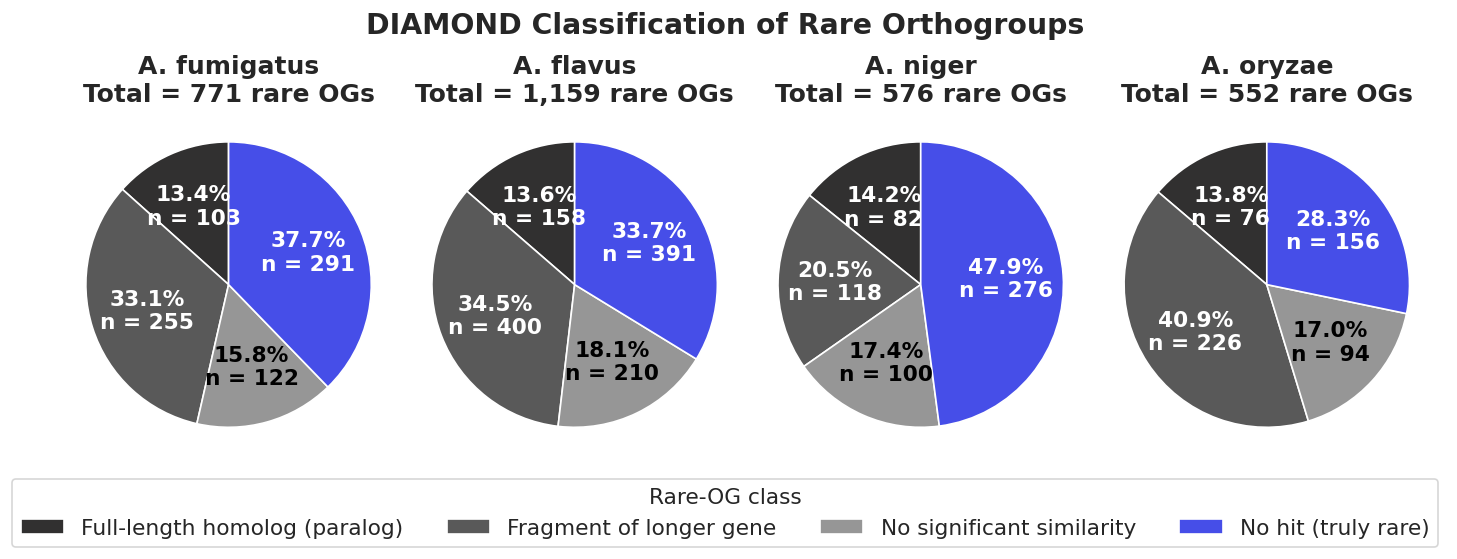

In [6]:
fig_pies = fphy.plot_diamond_classification_pies(NB4_RESULTS)
plt.show()

---
## Section 3: Truly-rare Filter

- Rare orthogroups outside the DIAMOND No-hit class are relabelled `Rare_excluded`
- `Pangenome_Class == 'Rare'` therefore means the truly-rare subset in every later section
- Requires Section 2

In [7]:
# Standalone bootstrap: run this cell to use Section 3 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')

species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)

Phenotype labels: 206 genomes

=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3


In [8]:
truly_rare_by_sp = fphy.apply_truly_rare_filter(
    SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR
)

  A. fumigatus  :   771 Rare ->   291 truly-rare kept |   480 reclassified as Rare_excluded (37.7 % kept)
  A. flavus     :  1159 Rare ->   391 truly-rare kept |   768 reclassified as Rare_excluded (33.7 % kept)
  A. niger      :   576 Rare ->   276 truly-rare kept |   300 reclassified as Rare_excluded (47.9 % kept)
  A. oryzae     :   552 Rare ->   156 truly-rare kept |   396 reclassified as Rare_excluded (28.3 % kept)


### 3.1 Per-genome burden table

- Truly-rare orthogroup count per genome, with species and phenotype labels
- Saved to `NB4_Results/rare_gene_burden_all_genomes.csv`

In [9]:
burden_all = fphy.build_full_genome_burden_table(
    SPECIES_LIST, species_data, SPECIES_CONFIG, pheno_map, fphy.get_accession, RESULTS_DIR
)

Total genomes with phenotype labels: 210
                                mean   std  count
Species      Phenotype                           
A. flavus    Animal-pathogenic  13.0   NaN      1
             Environmental      23.8   8.3      4
             Human-pathogenic   22.5  18.3     43
             Industrial-trait   13.5   4.9      2
             Plant-pathogenic   12.4  13.0     19
             Unknown            15.0   NaN      1
A. fumigatus Environmental       5.0   6.6     48
             Human-pathogenic   18.5  12.3     37
             Unknown             7.0   1.0      3
A. niger     Environmental      32.2  12.7      6
             Human-pathogenic   39.0   NaN      1
             Industrial-trait   25.3  17.8     12
A. oryzae    Environmental      38.0   NaN      1
             Industrial-trait   10.2   6.5     32

Saved: /datadrive/Analysis/NB4_Results/rare_gene_burden_all_genomes.csv


---
## Section 4: Compartment Characterisation

- Protein length, annotation rate and gene-model completeness across core, accessory, rare and truly-rare orthogroups
- Requires Sections 2 and 3

In [10]:
# Standalone bootstrap: run this cell to use Section 4 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')

species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)

truly_rare_by_sp = fphy.apply_truly_rare_filter(
    SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR
)

_inputs = fphy.prepare_rare_characterisation_inputs(
    SPECIES_LIST, species_data, SPECIES_CONFIG, SPECIES_DISPLAY,
    BASE_PATH, RESULTS_DIR, run_diamond=False
)
SPECIES_DEEP    = _inputs['species_deep']
length_data     = _inputs['length_data']
rates_df        = _inputs['rates_df']
diamond_results = _inputs['diamond_results']

Phenotype labels: 206 genomes

=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3
  A. fumigatus  :   771 Rare ->   291 truly-rare

### 4.1 Length and annotation summary table

- Median protein length per species and pangenome class
- Saved to `NB4_Results/rare_gene_characterisation_summary.csv`

In [11]:
class_order = ['Core', 'Accessory', 'Rare']
char_rows = []
for sp in SPECIES_DEEP:
    df_len = length_data.get(sp, pd.DataFrame())
    df_dia = diamond_results.get(sp, pd.DataFrame())

    for cls in class_order:
        sub = df_len[df_len['Pangenome_Class'] == cls] if not df_len.empty else pd.DataFrame()
        char_rows.append({
            'Species': f'A. {sp}',
            'Class': cls,
            'n_OGs': len(sub),
            'median_protein_len': sub['median_len'].median() if not sub.empty else np.nan,
        })

char_df = pd.DataFrame(char_rows)
char_df.to_csv(f'{RESULTS_DIR}/rare_gene_characterisation_summary.csv', index=False)
print(f'Saved: {RESULTS_DIR}/rare_gene_characterisation_summary.csv')
display(char_df)

Saved: /datadrive/Analysis/NB4_Results/rare_gene_characterisation_summary.csv


,Species,Class,n_OGs,median_protein_len
0,A. fumigatus,Core,8384,442.00
1,A. fumigatus,Accessory,1726,223.00
2,A. fumigatus,Rare,291,151.00
3,A. flavus,Core,10675,437.00
4,A. flavus,Accessory,2616,255.00
5,A. flavus,Rare,391,146.00
6,A. niger,Core,9422,440.00
7,A. niger,Accessory,2455,277.00
8,A. niger,Rare,276,140.25
9,A. oryzae,Core,11090,419.00


### 4.2 Compartment averages figure

- Mean per-orthogroup protein length, Pfam coverage and incomplete gene models per compartment
- A gene model counts as incomplete when it lacks a start codon or a terminal stop codon, its length is not divisible by three, or it lies within 100 bp of a contig edge
- Per-orthogroup lengths and per-gene ORF flags are cached in `og_length_by_class.csv` and `orf_completeness_by_class.csv`
- Saved to `NB4_Results/compartment_length_pfam_orf.png` and `.csv`

Loaded cached ORF completeness from orf_completeness_by_class.csv

Saved -> /datadrive/Analysis/NB4_Results/compartment_length_pfam_orf.png  and compartment_length_pfam_orf.csv

             length   pfam  incomplete
Compartment                           
Core         511.62  88.59        0.17
Accessory    318.57  71.66        1.40
Rare         276.70  62.97        5.87
Truly-rare   178.10  22.97        8.26


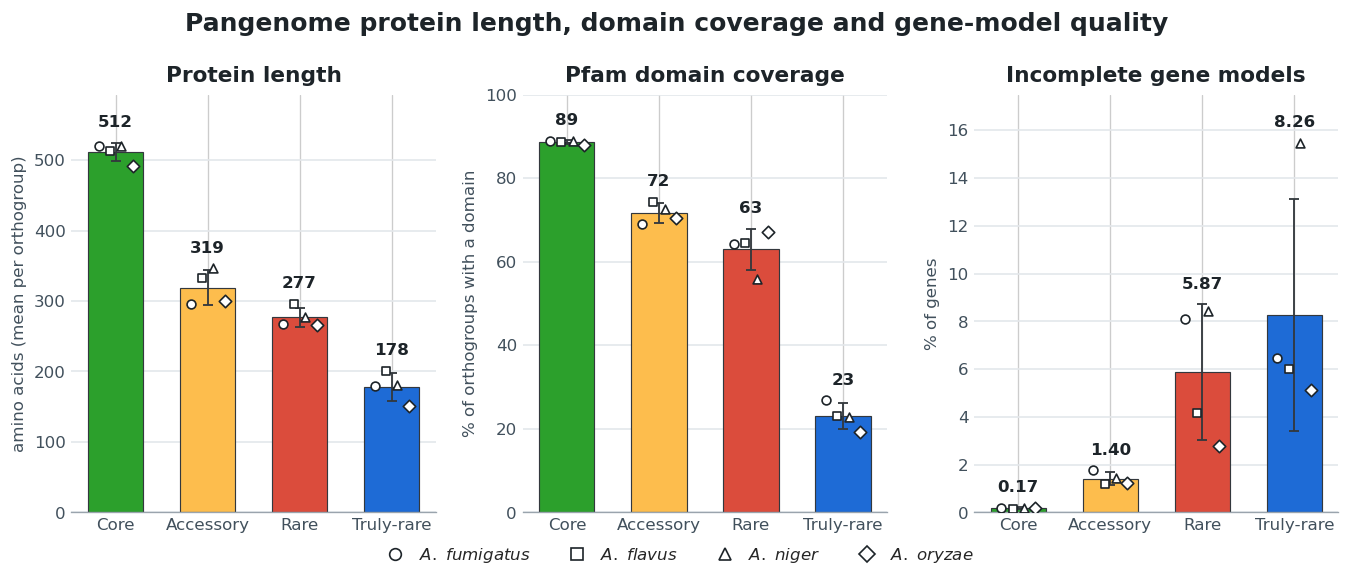

In [12]:
fig_comp, compartment_avg = fphy.plot_compartment_length_pfam_orf(
    NB1_RESULTS, NB4_RESULTS, BASE_PATH
)
plt.show()

---
## Section 5: COG Enrichment in the Truly-rare Compartment

- Fisher's exact test per COG category, truly-rare against the rest of the pangenome
- Benjamini-Hochberg FDR within each species
- Saved to `NB4_Results/cog_enrichment_rare_vs_nonrare.csv`

In [13]:
# Standalone bootstrap: run this cell to use Section 5 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')

species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)

truly_rare_by_sp = fphy.apply_truly_rare_filter(
    SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR
)

Phenotype labels: 206 genomes

=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3
  A. fumigatus  :   771 Rare ->   291 truly-rare

In [14]:
cog_enrich_df = fphy.run_rare_cog_enrichment(SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR)
sig = cog_enrich_df[cog_enrich_df['Significant']] if len(cog_enrich_df) > 0 else pd.DataFrame()
if len(sig) > 0:
    display(sig[['Species', 'COG', 'COG_description', 'Rare_count', 'NonRare_count',
                 'Odds_Ratio', 'q_value']].head(20))

Saved: /datadrive/Analysis/NB4_Results/cog_enrichment_rare_vs_nonrare.csv

Significant enrichments (FDR < 0.05): 0


---
## Section 6: Xenolog Detection

- Truly-rare orthogroups whose representative protein deviates from the species GC mean are queried against NCBI nr
- Per-orthogroup GC content is cached in `NB4_Results/{species}/og_gc_content.tsv`
- Requires network access; query results are cached in `NB4_Results/rare_xenolog_ncbi_blast_results.tsv`

In [15]:
# Standalone bootstrap: run this cell to use Section 6 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')

species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)

truly_rare_by_sp = fphy.apply_truly_rare_filter(
    SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR
)

Phenotype labels: 206 genomes

=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3
  A. fumigatus  :   771 Rare ->   291 truly-rare

In [16]:
# --- Tweakable parameters ---
FORCE_BLAST   = False    # True = re-BLAST every OG, ignore cache
FORCE_GC      = False    # True = recompute per-OG GC content, ignore cache
USE_GC_FILTER = True     # True = GC outliers only; False = first N_PER_SPECIES
GC_THRESHOLD  = 3.0      # SD cutoff for the GC filter
N_PER_SPECIES = 20       # only used if USE_GC_FILTER=False

# Candidate counts per species before any query is sent
if USE_GC_FILTER:
    print('Dry-run candidate counts:')
    _ = fphy.find_gc_outlier_rare_ogs(SPECIES_LIST, species_data, BASE_PATH,
                                      gc_threshold=GC_THRESHOLD,
                                      results_dir=RESULTS_DIR, force=FORCE_GC)
    print()

blast_df = fphy.run_ncbi_blast_xenologs(
    SPECIES_LIST, species_data, SPECIES_CONFIG,
    BASE_PATH, RESULTS_DIR,
    n_per_species=N_PER_SPECIES, force=FORCE_BLAST,
    gc_filter=USE_GC_FILTER, gc_threshold=GC_THRESHOLD,
)

if len(blast_df) > 0:
    org_cols = [c for c in ['organism', 'top_hit_organism', 'subject_organism']
                if c in blast_df.columns]
    if org_cols:
        print(f'\nTaxonomic origin distribution (top BLAST hits):')
        print(blast_df[org_cols[0]].value_counts().head(10).to_string())
    display(blast_df.head(20))

Dry-run candidate counts:
  fumigatus: GC content loaded from /datadrive/Analysis/NB4_Results/fumigatus/og_gc_content.tsv
  fumigatus: 16 GC outliers (|dev|>3.0 SD; mean GC=8.2%, n_rare=291)
  flavus: GC content loaded from /datadrive/Analysis/NB4_Results/flavus/og_gc_content.tsv
  flavus: 15 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=391)
  niger: GC content loaded from /datadrive/Analysis/NB4_Results/niger/og_gc_content.tsv
  niger: 13 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=276)
  oryzae: GC content loaded from /datadrive/Analysis/NB4_Results/oryzae/og_gc_content.tsv
  oryzae: 8 GC outliers (|dev|>3.0 SD; mean GC=8.3%, n_rare=156)

Backed up existing cache -> /datadrive/Analysis/NB4_Results/rare_xenolog_ncbi_blast_results.tsv.bak
Resuming: 72 (species, OG) pairs already in /datadrive/Analysis/NB4_Results/rare_xenolog_ncbi_blast_results.tsv
GC-deviation filter active (|GC_dev| > 3.0 SD); BLASTing all candidates (n_per_species ignored)
  fumigatus: GC content loaded from 

,species,orthogroup,accession,description,organism,pident,evalue
0,fumigatus,OG0010203,CAO5976858,Hypothetical protein CAMPOLS_039341 [Perkinsus...,Perkinsus olseni,33.532934,7.987880e-02
1,fumigatus,OG0010203,KAF3828726,hypothetical protein GH733_004632 [Mirounga le...,Mirounga leonina,26.011561,2.649090e+00
2,fumigatus,OG0010203,ETM02348,"hypothetical protein L917_01171, partial [Phyt...",Phytophthora nicotianae,36.507937,4.555910e+00
3,fumigatus,OG0010213,KAH1796053,hypothetical protein KXX36_002078 [Aspergillus...,Aspergillus fumigatus,93.243243,1.264200e-90
4,fumigatus,OG0010213,EDP48471,"hypothetical protein AFUB_091880, partial [Asp...",Aspergillus fumigatus A1163,100.000000,3.539420e-75
5,fumigatus,OG0010213,XP_748877,uncharacterized protein AFUA_7G06330 [Aspergil...,Aspergillus fumigatus Af293,98.260870,7.707080e-75
6,fumigatus,OG0010213,RECOVERED,(top-1 hit reconstructed from prior session ou...,Aspergillus fumigatus,93.243243,1.264200e-90
7,fumigatus,OG0010279,RECOVERED,(top-1 hit reconstructed from prior session ou...,Bacteroidota bacterium,38.571429,2.215110e+00
8,fumigatus,OG0010332,RECOVERED,(top-1 hit reconstructed from prior session ou...,Aspergillus fumigatus,87.234043,5.384970e-15
9,fumigatus,OG0010503,RECOVERED,(top-1 hit reconstructed from prior session ou...,Aspergillus fumigatus,100.000000,8.745640e-57


### 6.1 Taxonomy of the top hits

- Top hit per orthogroup, grouped by kingdom
- Confident xenologs are non-fungal top hits at or below the e-value cutoff
- Saved to `NB4_Results/rare_xenolog_taxonomy.png`, `rare_xenolog_kingdom_summary.csv` and `rare_xenolog_confident_hits.csv`

Restricting BLAST table to truly-rare OGs: 92 -> 64 rows (28 hits dropped from now-Rare_excluded OGs)
Saved: /datadrive/Analysis/NB4_Results/rare_xenolog_taxonomy.png

Saved: /datadrive/Analysis/NB4_Results/rare_xenolog_kingdom_summary.csv



kingdom_filtered,Aspergillus (self),Other fungi,Bacteria,Protist,Plant,Animal,Virus,Unknown,Weak / no hit,Total,Confident xenologs
species,,,,,,,,,,,
flavus,10,0,1,0,0,0,0,0,1,12,1
fumigatus,9,0,0,0,0,1,0,0,2,12,1
niger,11,0,0,0,0,0,0,0,0,11,0
oryzae,6,0,0,0,0,0,0,0,1,7,0


Confident non-fungal top hits: 2
Saved: /datadrive/Analysis/NB4_Results/rare_xenolog_confident_hits.csv


,species,orthogroup,organism,kingdom,pident,evalue
41,flavus,OG0014462,Stenotrophomonas maltophilia,Bacteria,98.369565,0.000000e+00
6,fumigatus,OG0010578,Rhipicephalus sanguineus,Animal,96.470588,1.135070e-23


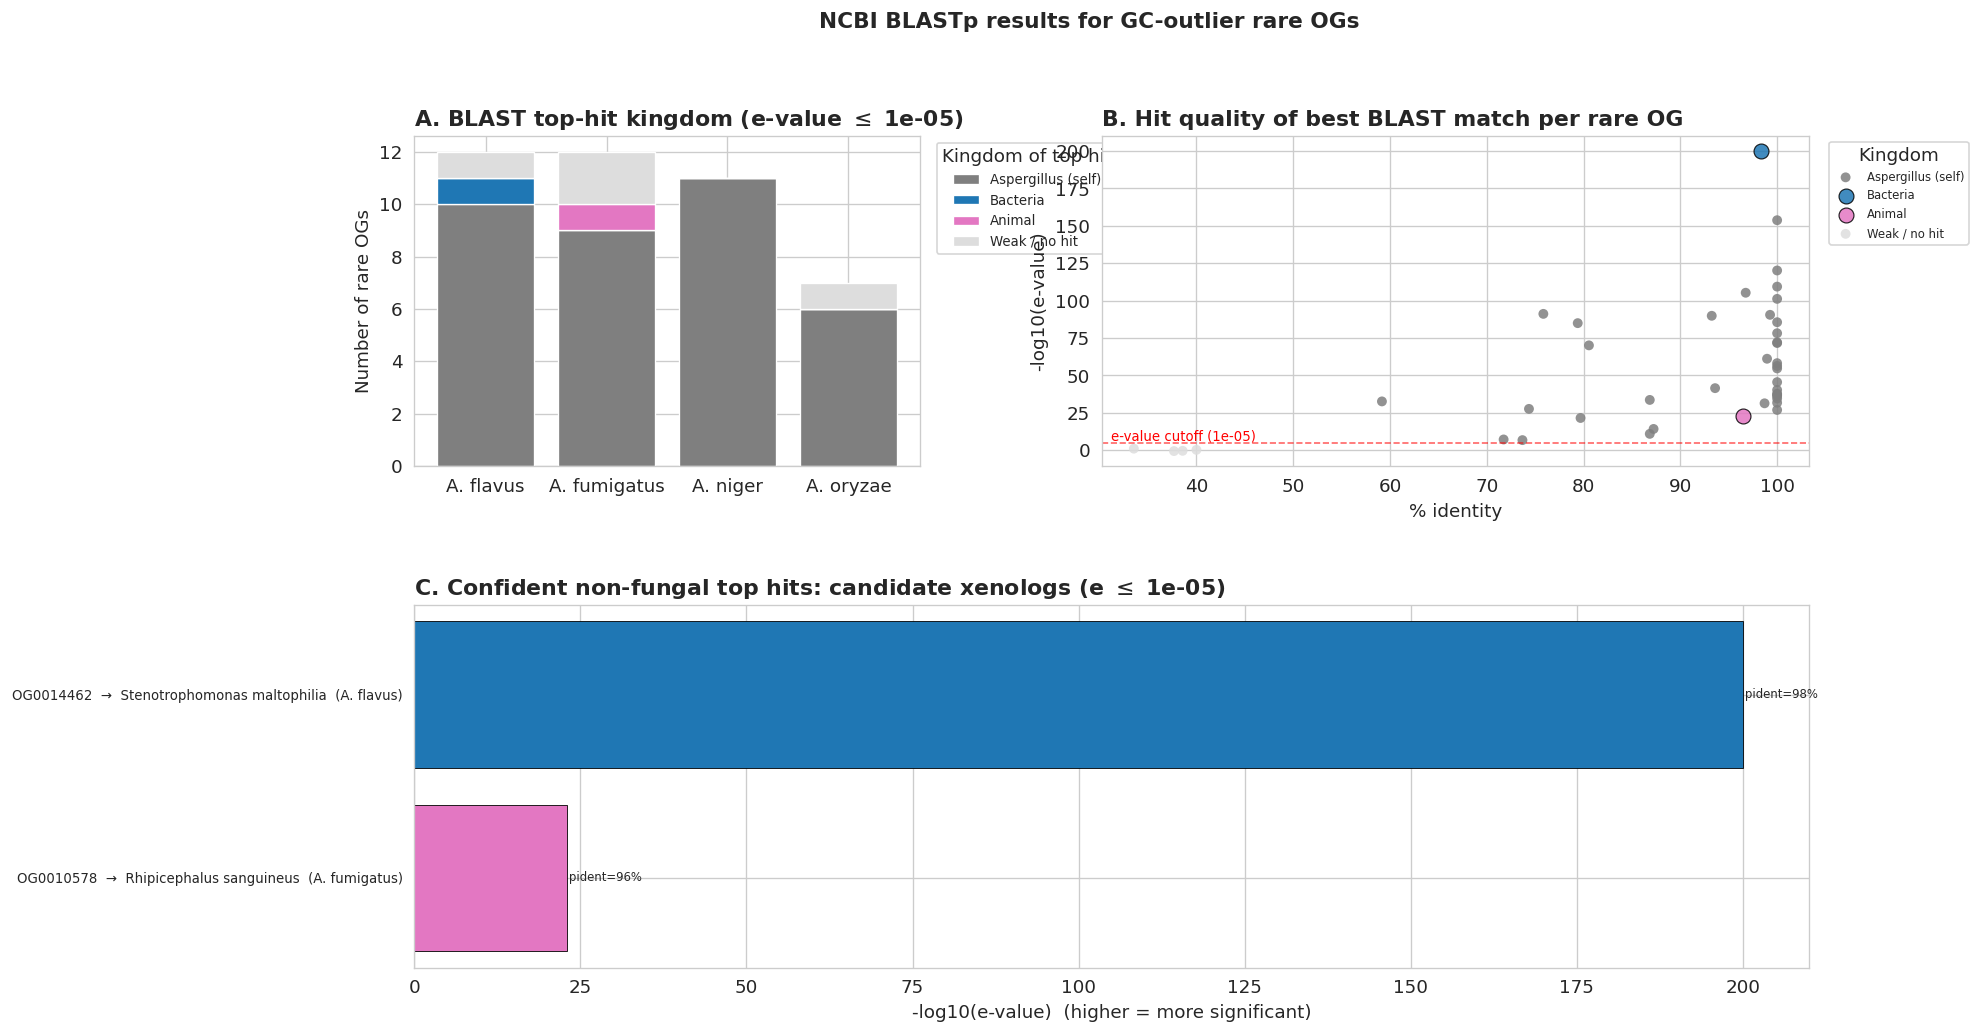

In [17]:
# --- Tweakable parameters ---
EVALUE_CUTOFF = 1e-5

if 'truly_rare_by_sp' in dir() and len(truly_rare_by_sp):
    n_before = len(blast_df)
    keep_pairs = {(sp, og) for sp, ogs in truly_rare_by_sp.items() for og in ogs}
    blast_df = blast_df[blast_df.apply(
        lambda r: (str(r['species']), str(r['orthogroup'])) in keep_pairs,
        axis=1)].copy()
    print(f'Restricting BLAST table to truly-rare OGs: '
          f'{n_before} -> {len(blast_df)} rows '
          f'({n_before - len(blast_df)} hits dropped from now-Rare_excluded OGs)')

xeno_top = fphy.plot_xenolog_taxonomy(
    blast_df, SPECIES_CONFIG, RESULTS_DIR, evalue_cutoff=EVALUE_CUTOFF
)

# Kingdom counts per species
summary = (xeno_top.groupby(['species', 'kingdom_filtered']).size()
                  .unstack(fill_value=0)
                  .reindex(columns=['Aspergillus (self)', 'Other fungi',
                                    'Bacteria', 'Protist', 'Plant', 'Animal',
                                    'Virus', 'Unknown', 'Weak / no hit'],
                           fill_value=0))
summary['Total'] = summary.sum(axis=1)
summary['Confident xenologs'] = summary[['Bacteria', 'Protist', 'Plant',
                                          'Animal', 'Virus']].sum(axis=1)
summary.to_csv(f'{RESULTS_DIR}/rare_xenolog_kingdom_summary.csv')
print(f'\nSaved: {RESULTS_DIR}/rare_xenolog_kingdom_summary.csv\n')
display(summary)

# Non-fungal top hits
confident = xeno_top[
    ~xeno_top['kingdom_filtered'].isin(['Aspergillus (self)', 'Other fungi',
                                         'Weak / no hit', 'Unknown'])
].sort_values('evalue').copy()
confident.to_csv(f'{RESULTS_DIR}/rare_xenolog_confident_hits.csv', index=False)
print(f'Confident non-fungal top hits: {len(confident)}')
print(f'Saved: {RESULTS_DIR}/rare_xenolog_confident_hits.csv')
if len(confident) > 0:
    display(confident[['species', 'orthogroup', 'organism', 'kingdom',
                        'pident', 'evalue']])

### 6.2 Genomic neighbourhood of the confident xenologs

- Genes flanking each confident xenolog on its contig, coloured by pangenome class
- Gene to orthogroup assignments are read per genome column, since gene IDs repeat across genomes
- Labels come from the per-genome eggNOG annotations
- Saved to `NB4_Results/xenolog_neighbourhood.png`


OG0014462 GCA_052815365.1 scaffold_69:
   FUN_012562 [Core      70] permease
   FUN_012563 [Rare       1] restriction endonuclease
   FUN_012564 [Rare       1] plasmid rep (KfrA)
   FUN_012565 [Rare       1] phage protein
   FUN_012566 [Rare       1] hypothetical
   FUN_012567 [Rare       1] hypothetical
   FUN_012568 [Rare       1] phage ssDNA-binding
   FUN_012569 [XENOLOG    1] Zot toxin
   FUN_012570 [Rare       1] phage protein
   FUN_012571 [Rare       1] hypothetical
   FUN_012572 [Rare       1] hypothetical
   FUN_012573 [Rare       1] phage ssDNA-binding
   FUN_012574 [XENOLOG    1] Zot toxin

OG0010936 GCA_049901915.1 scaffold_31:
   FUN_006530 [Core      89] MFS transporter
   FUN_006531 [Rare       1] hypothetical
   FUN_006532 [XENOLOG    1] DUF3299 (bacterial)
   FUN_006533 [XENOLOG    1] DUF3299 (bacterial)
   FUN_006534 [Rare       1] FtsX/MacB transporter
   FUN_006535 [Rare       1] DUF2796
   FUN_006536 [Rare       1] LysR regulator
   FUN_006537 [Core      89] aldo

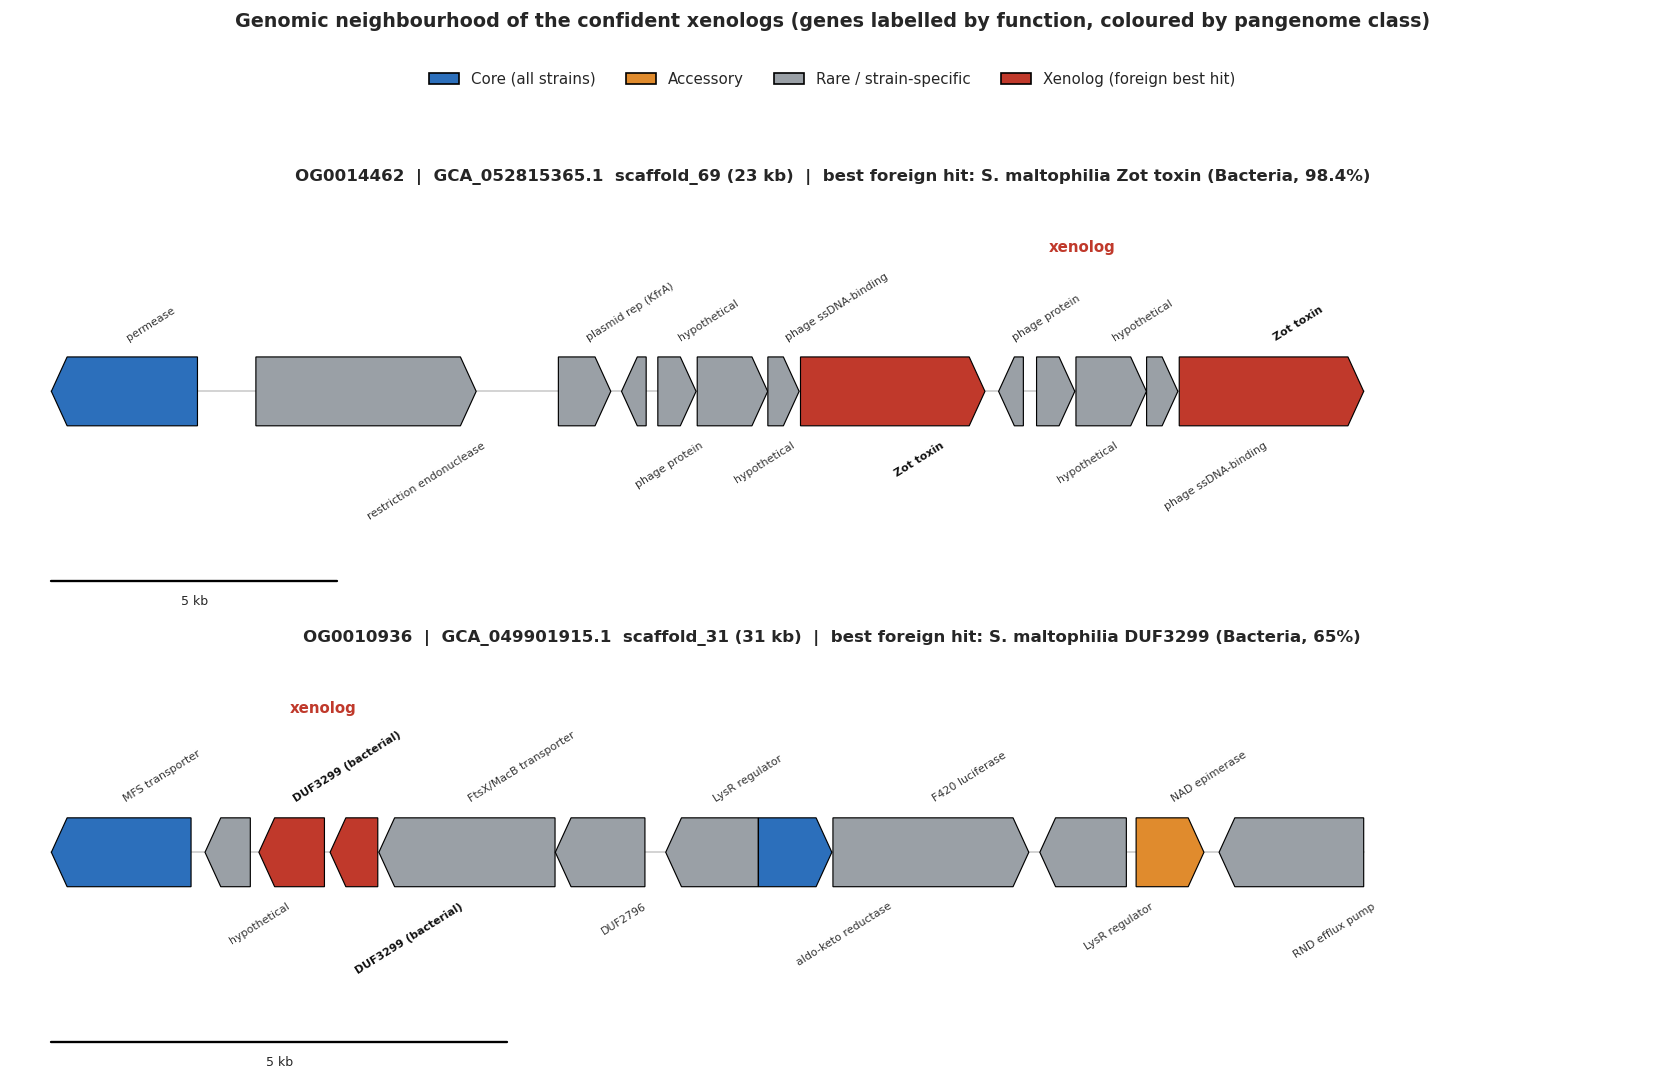

In [18]:
fig_xen = fphy.plot_xenolog_neighbourhood(BASE_PATH, RESULTS_DIR)
plt.show()

---
## Section 7: Phylogenetic Signal and Ancestral Reconstruction

- Fritz and Purvis D for each phenotype against the recombination-corrected IQ-TREE phylogeny, with a 1,000-permutation null
- Fitch parsimony ancestral niche reconstruction and per-orthogroup gain and loss counts
- Requires the per-species IQ-TREE output from the pipeline
- Saved under `NB4_Results/{species}/`

In [19]:
# Standalone bootstrap: run this cell to use Section 7 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

pheno_path = NB0_RESULTS / 'phenotype_classified_for_gwas.csv'
pheno_df = pd.read_csv(pheno_path)
pheno_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Phenotype']))
species_map = dict(zip(pheno_df['Assembly Accession'], pheno_df['Species']))
print(f'Phenotype labels: {len(pheno_map)} genomes')

species_data = fphy.load_nb4_species_data(
    SPECIES_LIST, GENUS, BASE_PATH, NB1_RESULTS, ani_excluded=fpu.ANI_EXCLUDED
)

truly_rare_by_sp = fphy.apply_truly_rare_filter(
    SPECIES_LIST, species_data, SPECIES_CONFIG, RESULTS_DIR
)

Phenotype labels: 206 genomes

=== fumigatus ===
  Loaded cached PAV ((10951, 88)) and CNV ((10951, 88)) from /datadrive/Analysis/NB1_Results/fumigatus

=== flavus ===
  Loaded cached PAV ((14463, 70)) and CNV ((14463, 70)) from /datadrive/Analysis/NB1_Results/flavus

=== niger ===
  Loaded cached PAV ((12453, 19)) and CNV ((12453, 19)) from /datadrive/Analysis/NB1_Results/niger

=== oryzae ===
  Loaded cached PAV ((14279, 33)) and CNV ((14279, 33)) from /datadrive/Analysis/NB1_Results/oryzae
  fumigatus: dropped 686 OGs private to excluded genomes
  fumigatus: PAV (10951, 88), OG consensus (10881, 23), 771 rare OGs, core>=84, rare<=6
  flavus: dropped 497 OGs private to excluded genomes
  flavus: PAV (14463, 70), OG consensus (14450, 23), 1159 rare OGs, core>=68, rare<=6
  niger: PAV (12453, 19), OG consensus (12453, 23), 576 rare OGs, core>=18, rare<=2
  oryzae: PAV (14279, 33), OG consensus (14279, 23), 552 rare OGs, core>=31, rare<=3
  A. fumigatus  :   771 Rare ->   291 truly-rare


A. fumigatus -- Phylogenetic Analysis
  Loading tree from: /datadrive/Species/Aspergillus/fumigatus/iqtree_output_snv/gubbins_tree.contree
  Pruned ANI-excluded: GCA_049901915.1
  Tree: 88 tips

  --- Fritz & Purvis D (phylogenetic signal) ---
  Phenotypes in tree: {'Environmental', 'Human-pathogenic'}
    Environmental: D=0.005, p(random)=0.000 *
    Human-pathogenic: D=0.016, p(random)=0.000 *
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/phylogenetic_signal.png

  --- Gene gain/loss events ---
  Gain/loss events: 2017 OGs analysed
  Mean parsimony changes: 10.69
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/gain_loss_events.tsv
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/gain_loss_summary.tsv

  --- Ancestral niche reconstruction ---
  Saved: /datadrive/Analysis/NB4_Results/fumigatus/ancestral_niche_reconstruction.png

A. flavus -- Phylogenetic Analysis
  Loading tree from: /datadrive/Species/Aspergillus/flavus/iqtree_output_snv/gubbins_tree.contree
  Pruned ANI-ex

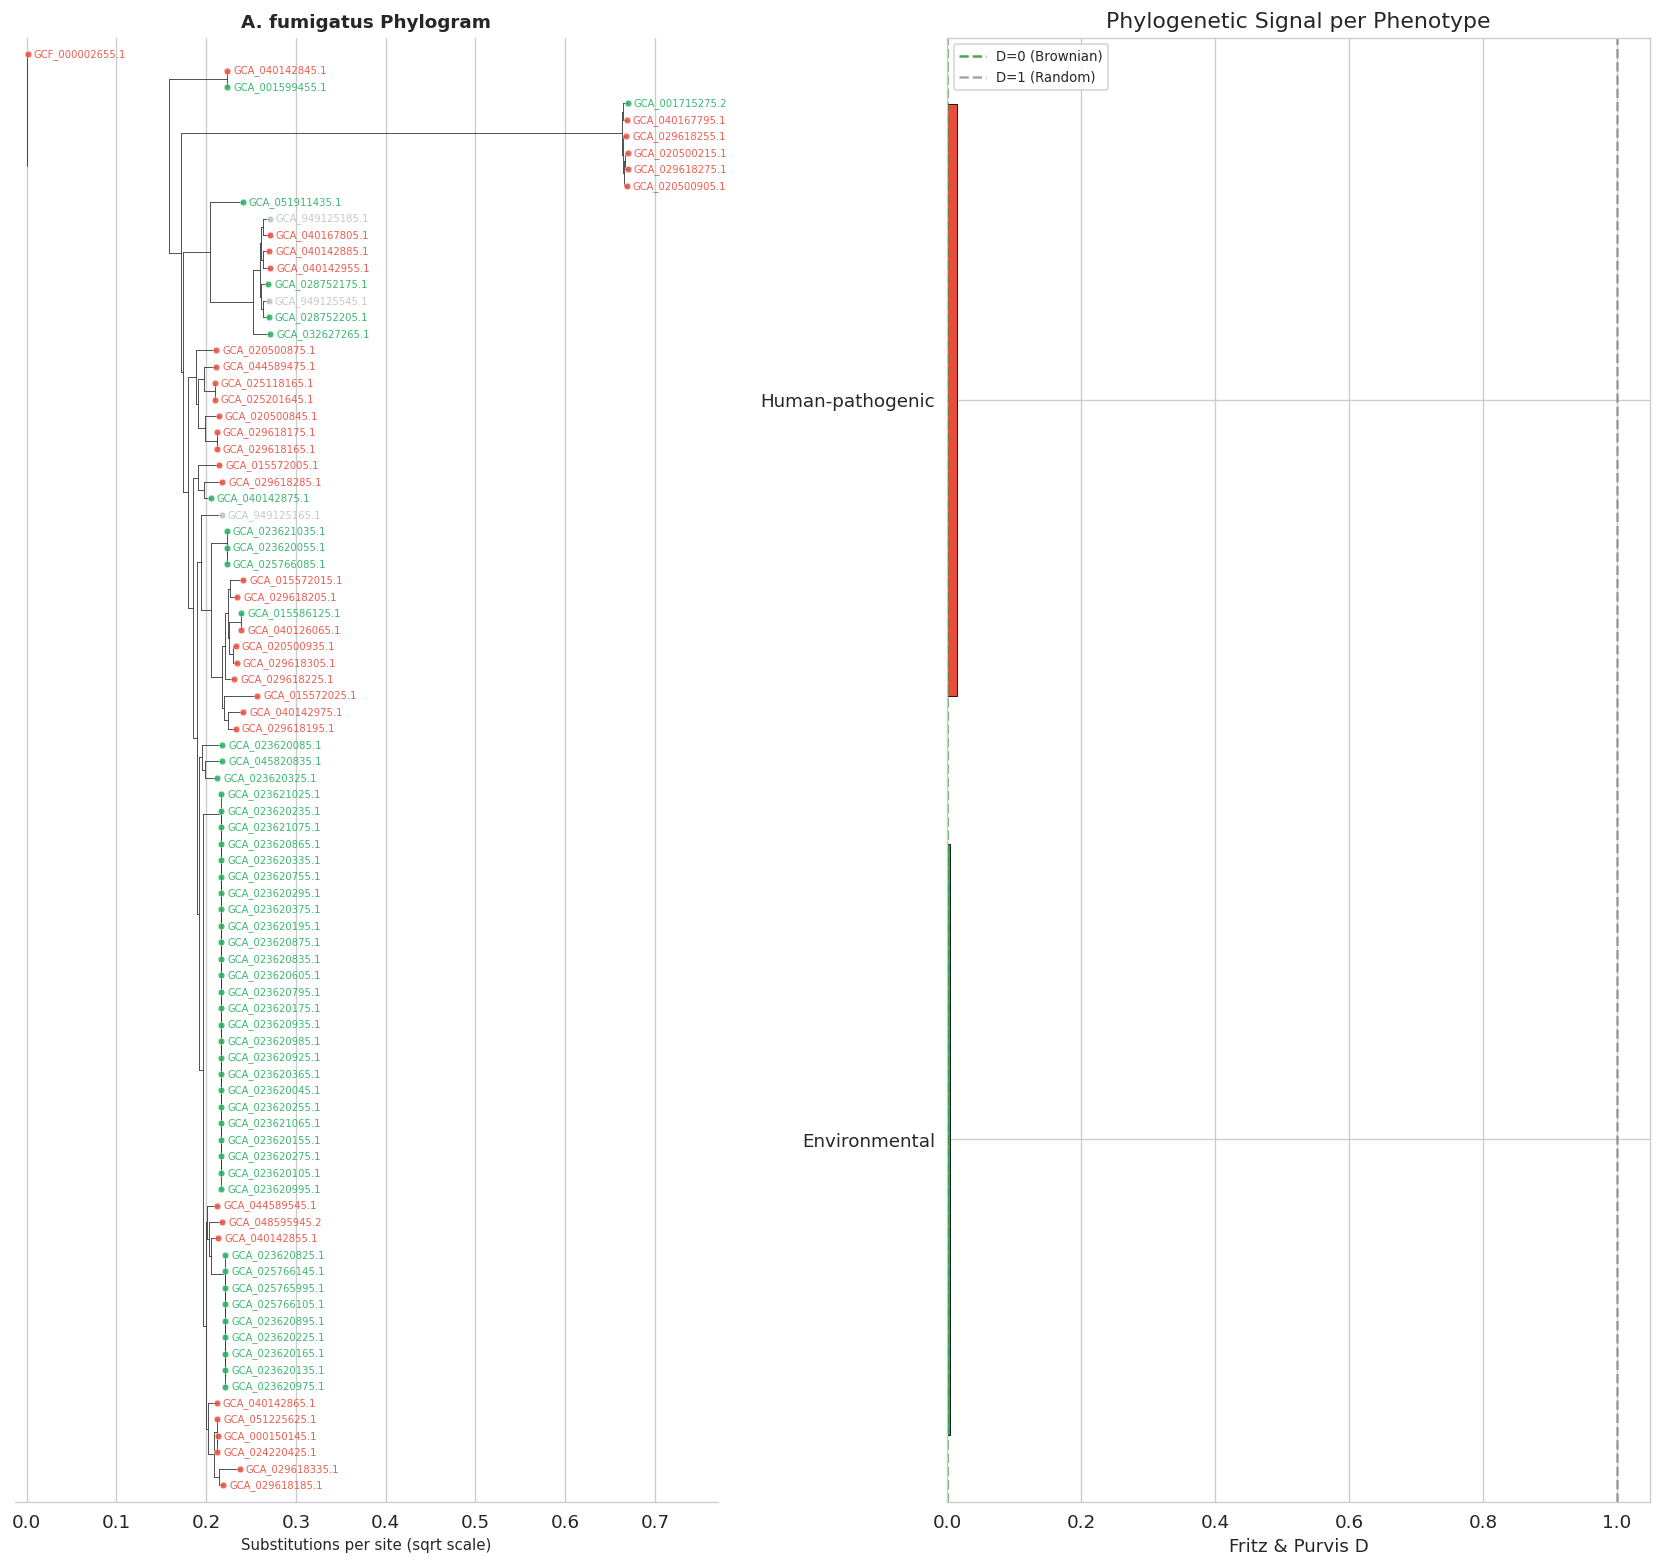

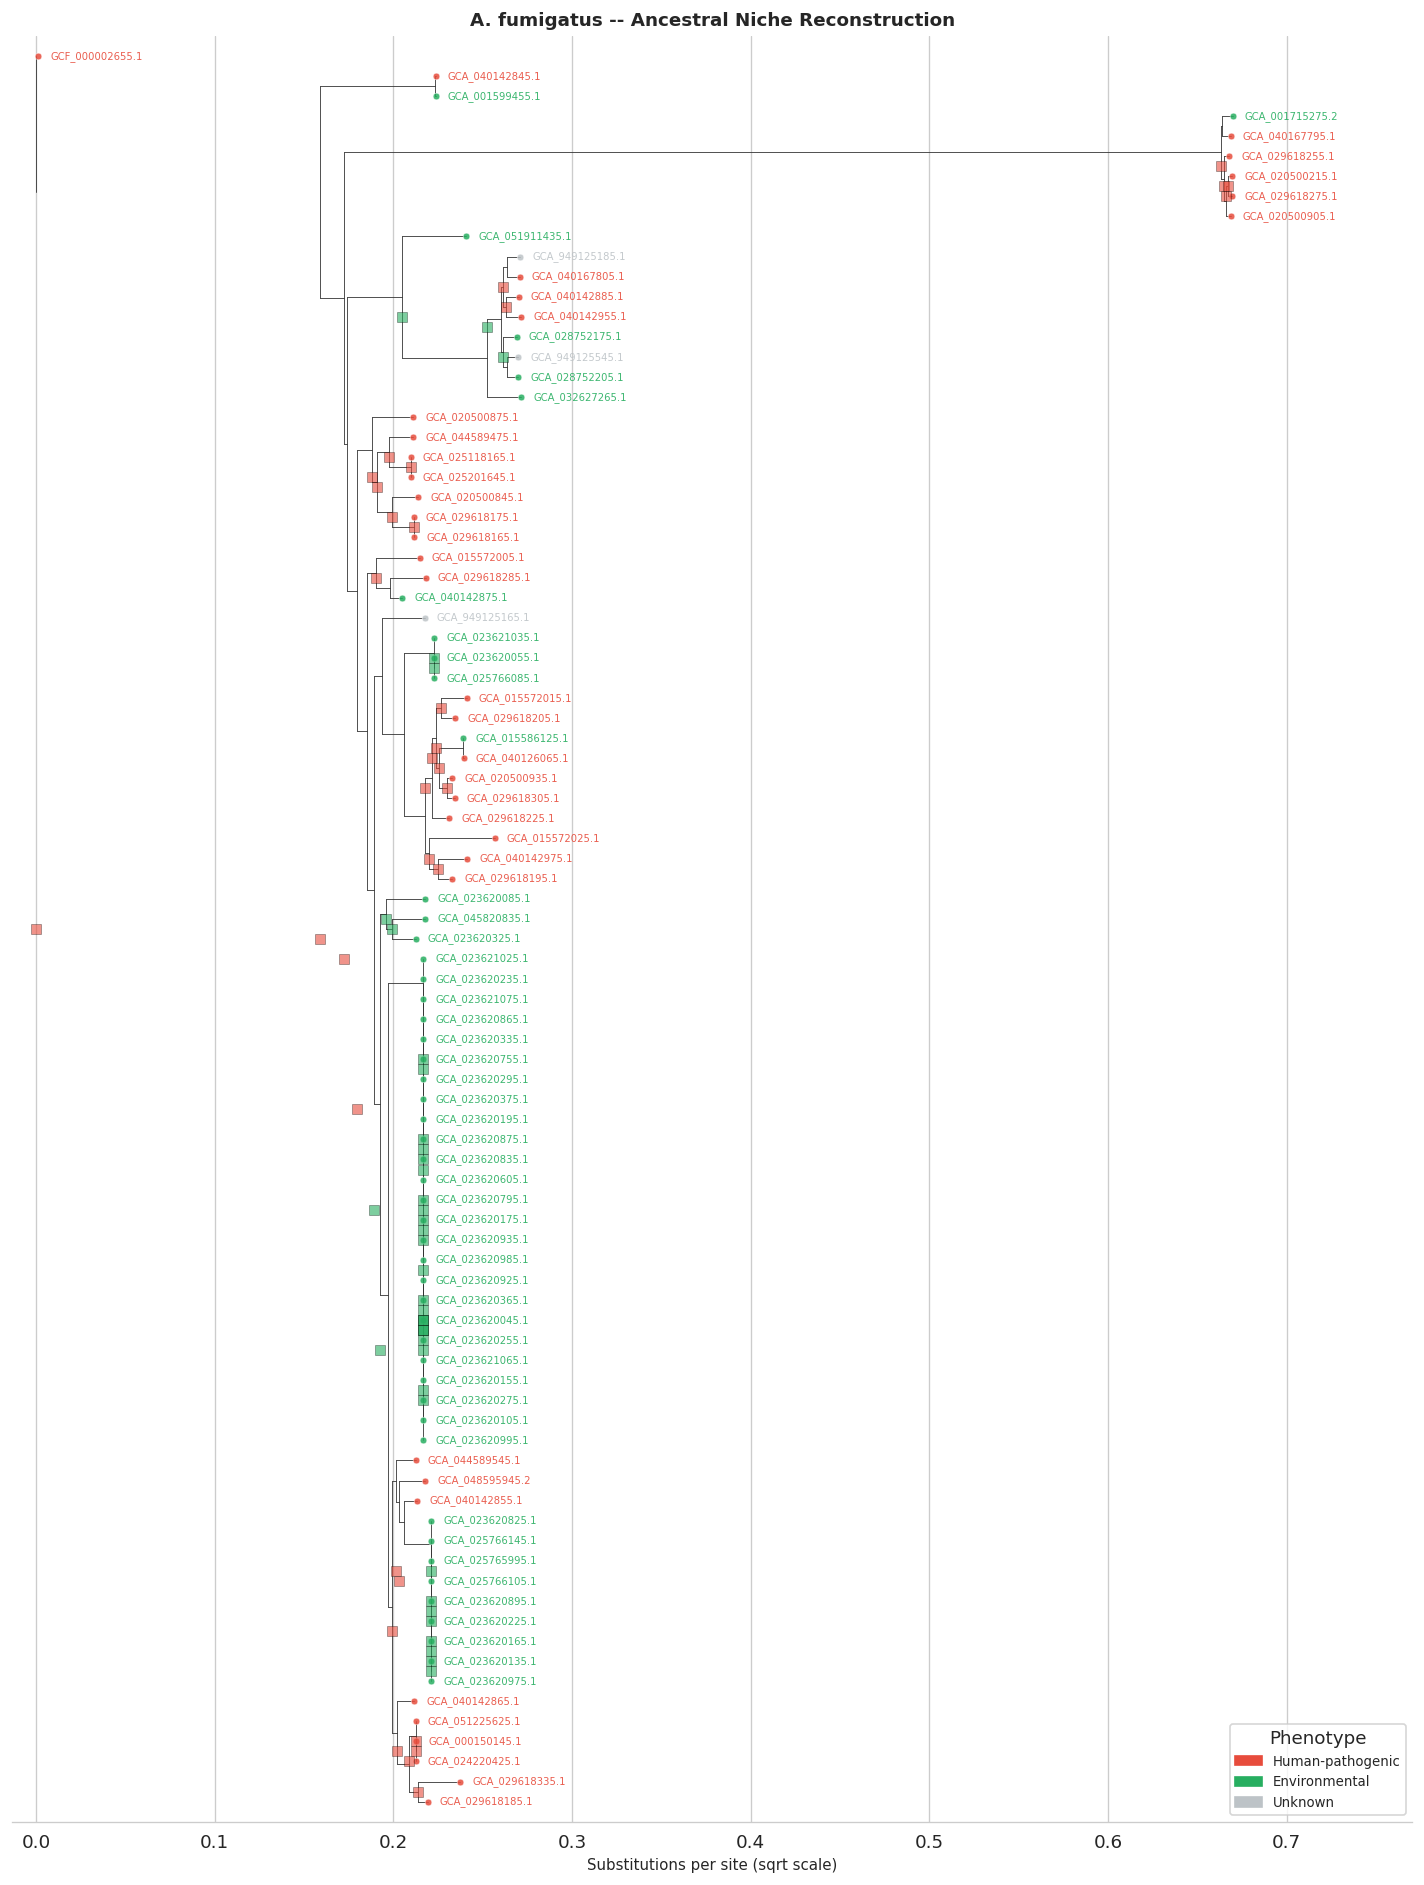

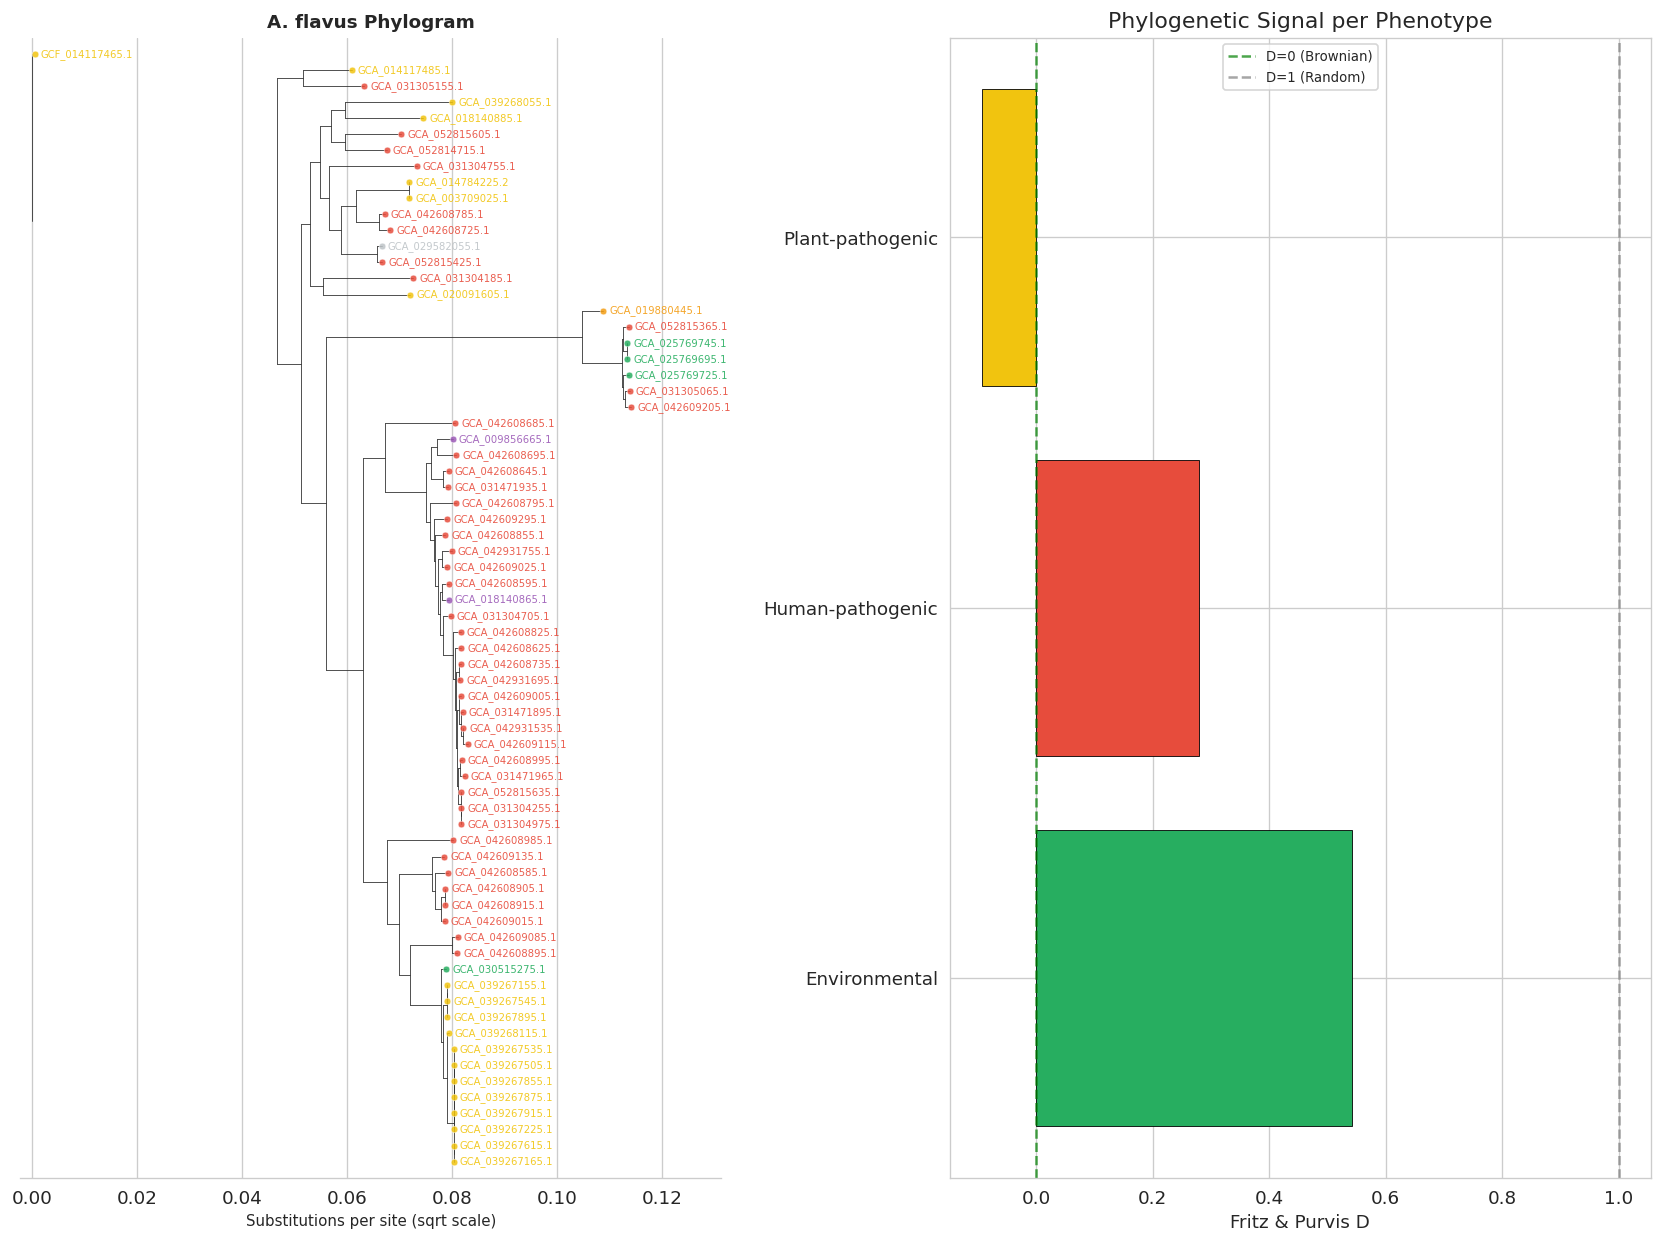

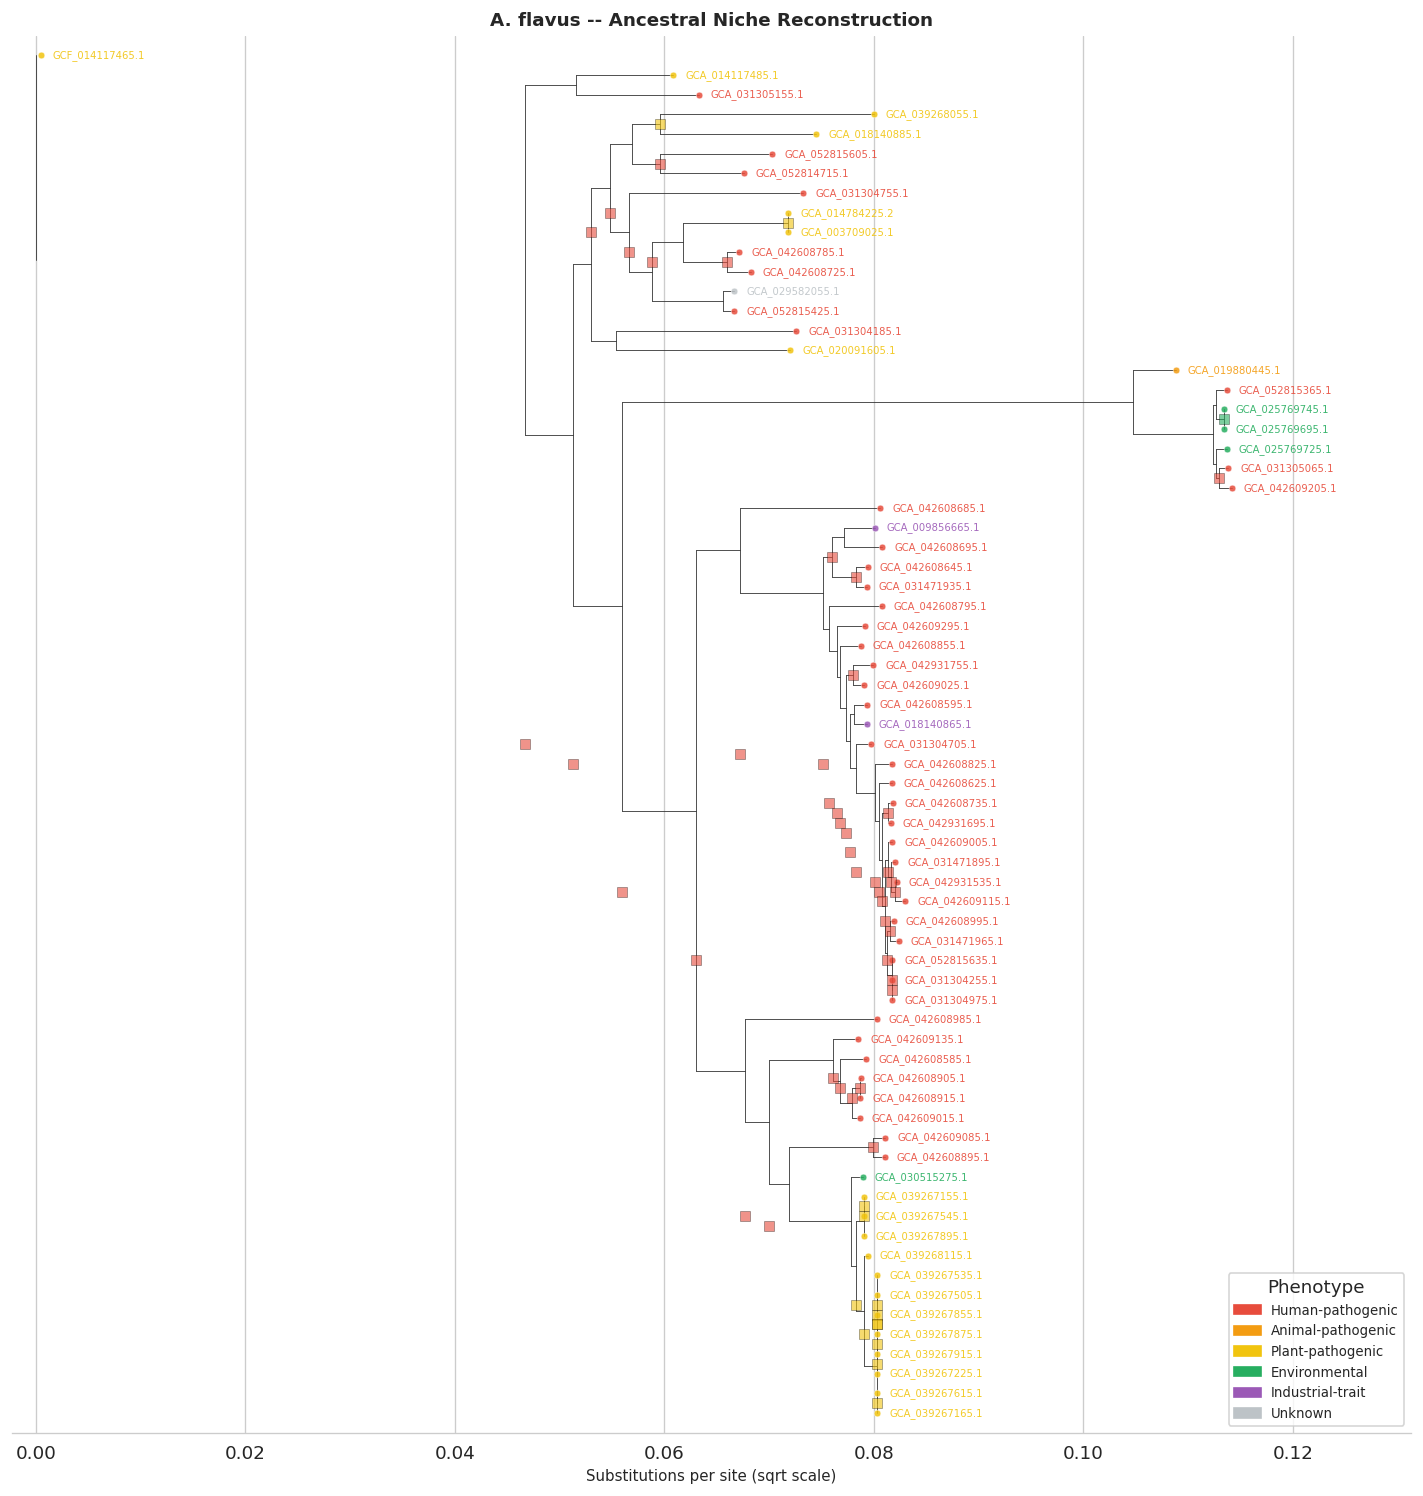

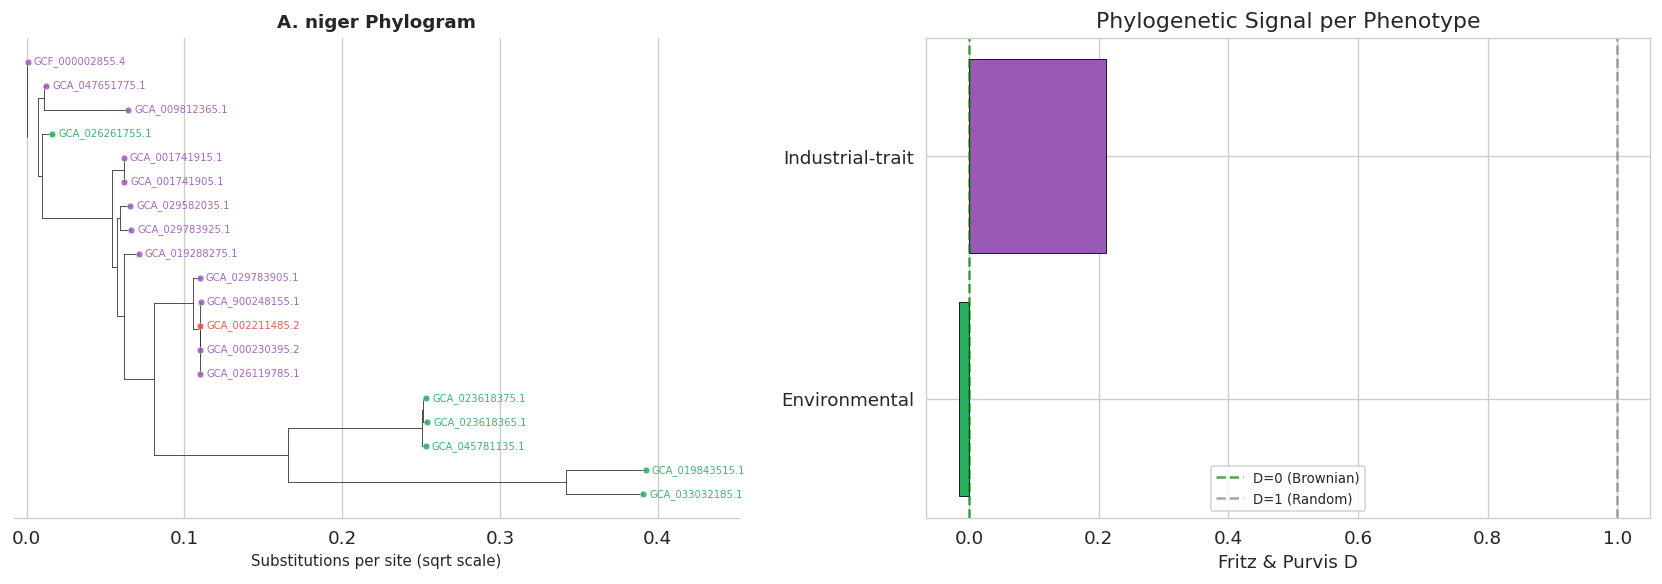

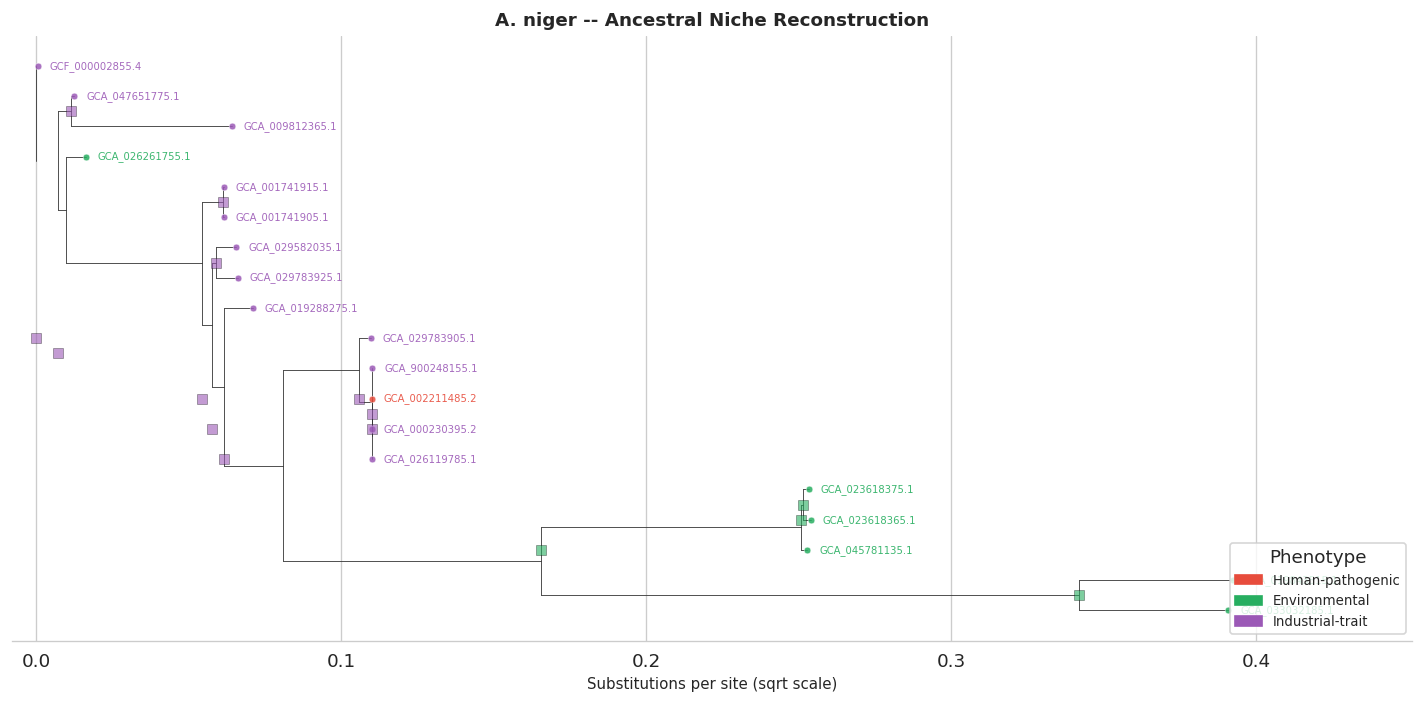

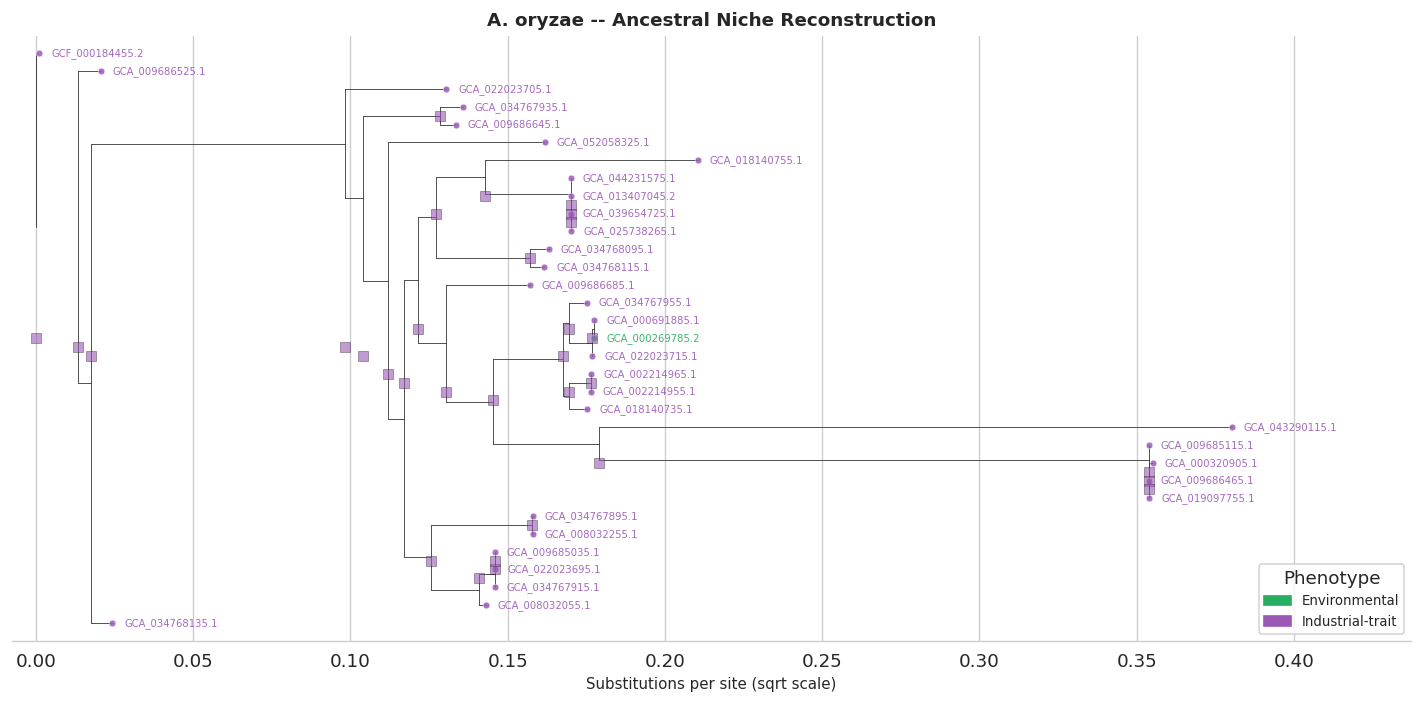

In [20]:
fphy.run_phylogenetic_analysis_all_species(
    SPECIES_LIST, species_data, SPECIES_CONFIG,
    pheno_map, pheno_df, RESULTS_DIR,
    genus=GENUS, ani_excluded=ANI_EXCLUDED, transform='sqrt'
)

---
## Section 8: Mash Clustering

- Pairwise Mash distances, sketch size 1,000 and k = 21
- Requires the `mash` binary on PATH
- Saved under `NB4_Results/mash_clustering/`

In [21]:
# Standalone bootstrap: run this cell to use Section 8 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

meta_path = NB0_RESULTS / 'qc_passed_classified_all.csv'
df_meta_mash = pd.read_csv(meta_path)
acc_to_phenotype = dict(zip(
    df_meta_mash['Assembly Accession'].str.extract(r'(GC[AF]_\d+\.\d+)')[0],
    df_meta_mash['Phenotype']
))

### 8.1 Per-species distances

- One distance matrix and heatmap per species

In [22]:
SPECIES_LIST_MASH = ['fumigatus', 'flavus', 'niger', 'oryzae']
SPECIES_DISPLAY_MASH = {
    'fumigatus': 'A. fumigatus', 'flavus': 'A. flavus',
    'niger': 'A. niger', 'oryzae': 'A. oryzae',
}

mash_results = fphy.run_mash_per_species(
    SPECIES_LIST_MASH, SPECIES_DISPLAY_MASH, GENUS, ANI_EXCLUDED, RESULTS_DIR
)


  A. fumigatus - Mash Distance Computation
  Found 88 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/fumigatus/fumigatus_distances.tsv
  Distance matrix shape: (88, 88)

  A. flavus - Mash Distance Computation
  Found 70 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/flavus/flavus_distances.tsv
  Distance matrix shape: (70, 70)

  A. niger - Mash Distance Computation
  Found 19 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/niger/niger_distances.tsv
  Distance matrix shape: (19, 19)

  A. oryzae - Mash Distance Computation
  Found 33 genome files
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/oryzae/oryzae_distances.tsv
  Distance matrix shape: (33, 33)

Per-species Mash distance computation complete!
  A. fumigatus: 88 genomes
  A. flavus: 70 genomes
  A. niger: 19 genomes

### 8.2 K-means clustering

- Optimal k chosen by silhouette and elbow criteria, per species


  A. fumigatus - Mash Clustering
  Optimal k=2 (silhouette peak k=2 close to elbow k=4; using silhouette)
  Cluster sizes:
    M1: 82
    M2: 6

  A. flavus - Mash Clustering
  Optimal k=5 (silhouette peak k=5 close to elbow k=4; using silhouette)
  Cluster sizes:
    M1: 13
    M2: 9
    M3: 6
    M4: 17
    M5: 25

  A. niger - Mash Clustering
  Optimal k=3 (silhouette peak k=5 too high for n=19 (avg cluster < 5); trusting elbow)
  Cluster sizes:
    M1: 3
    M2: 14
    M3: 2

  A. oryzae - Mash Clustering
  Optimal k=3 (silhouette peak k=15 too high for n=33 (avg cluster < 5); trusting elbow)
  Cluster sizes:
    M1: 21
    M2: 5
    M3: 7


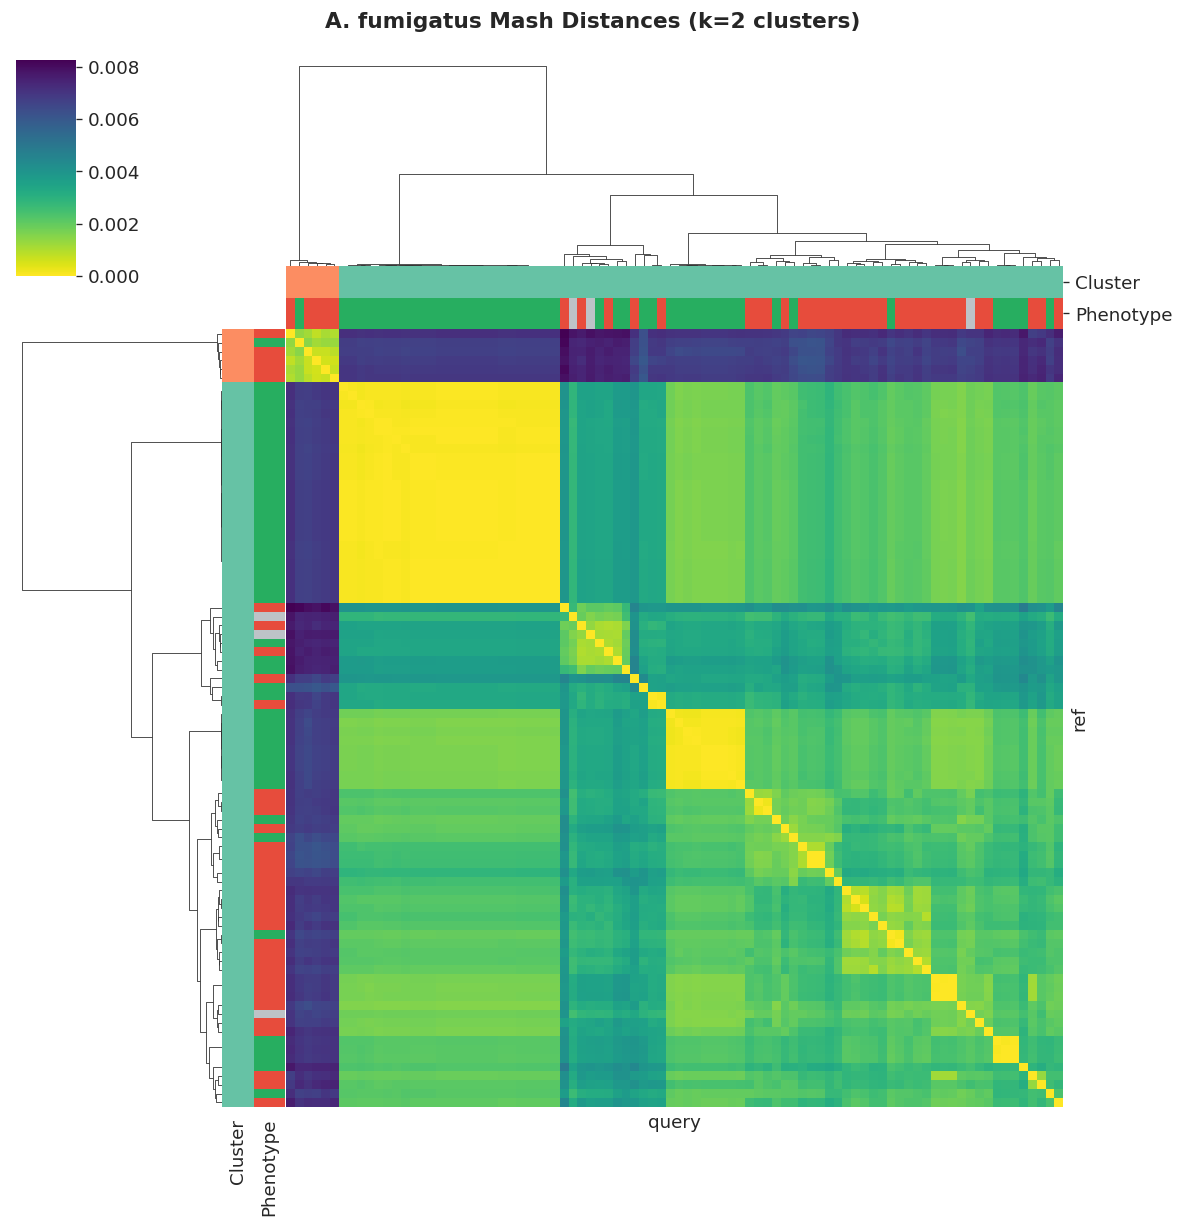

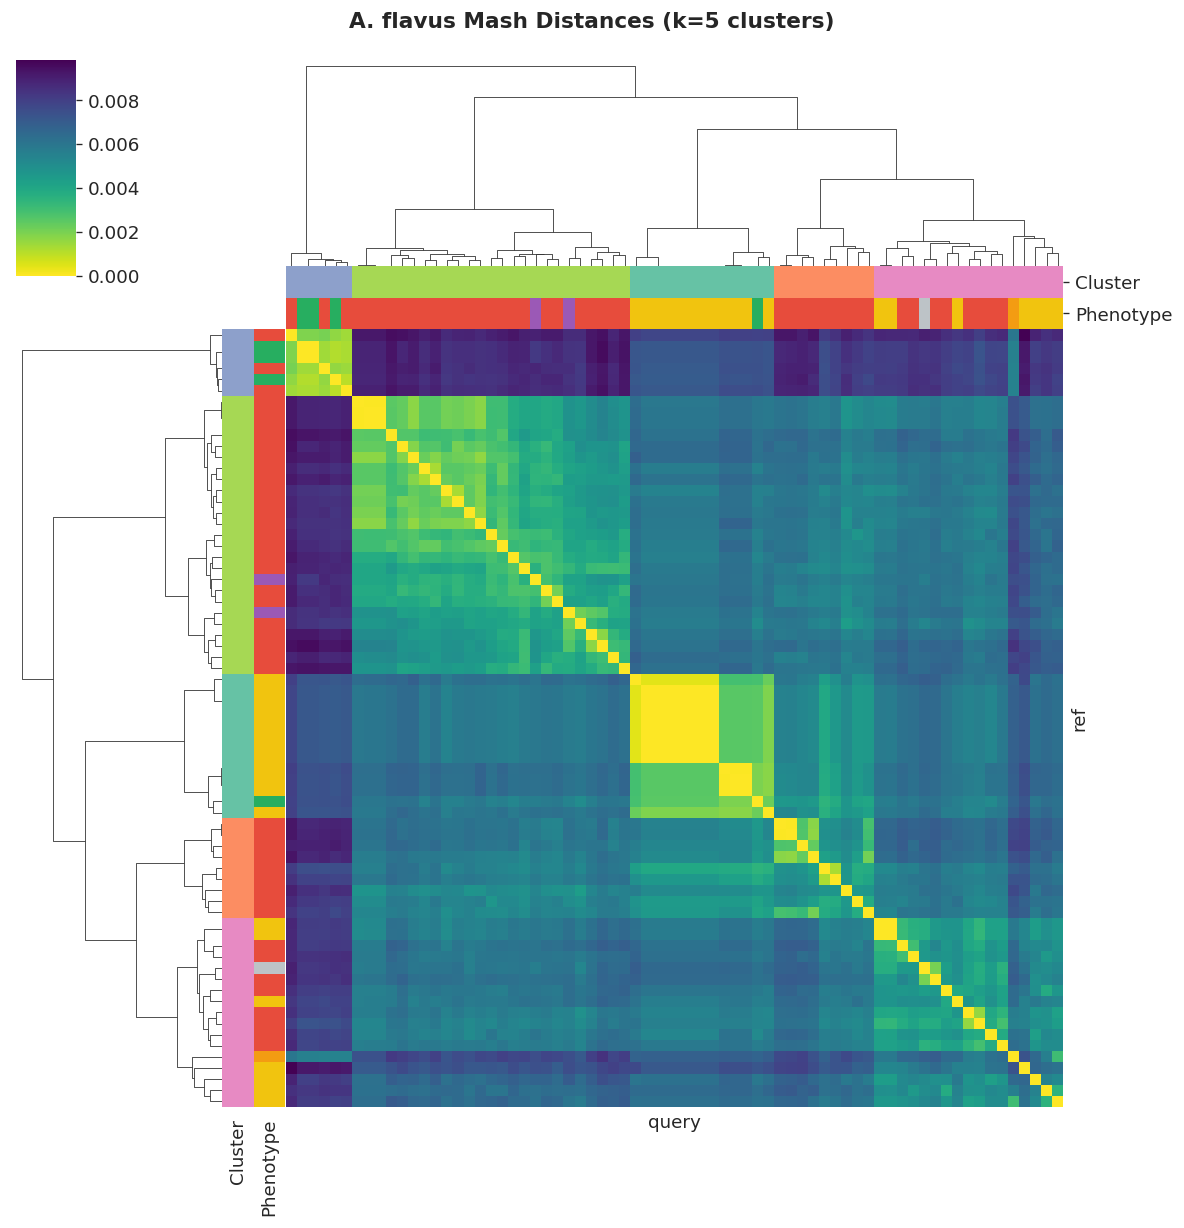

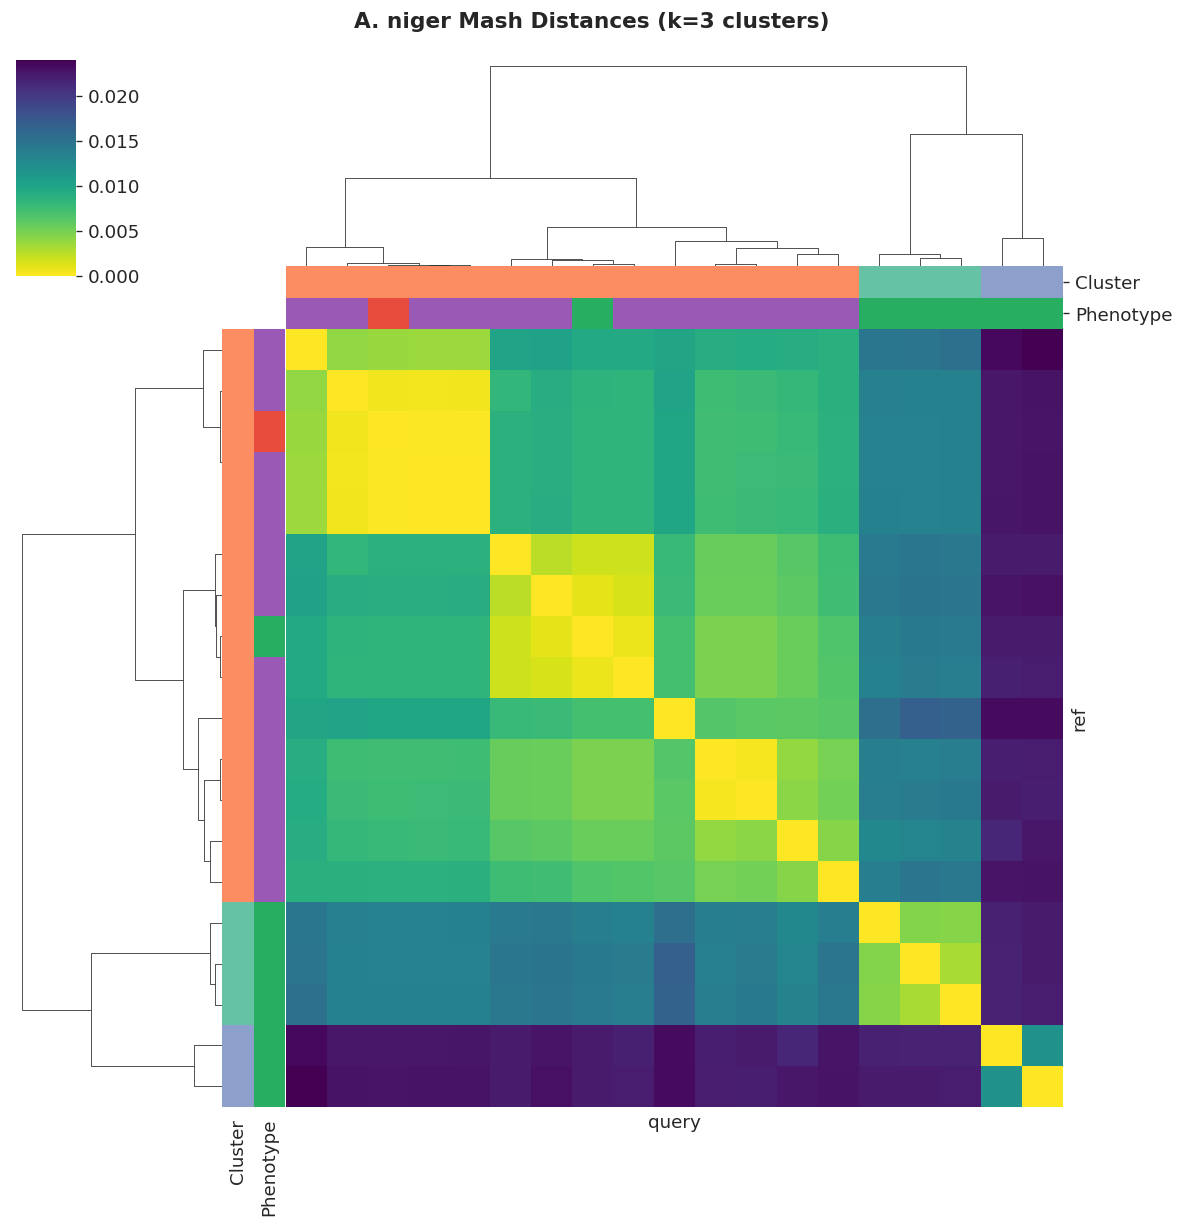

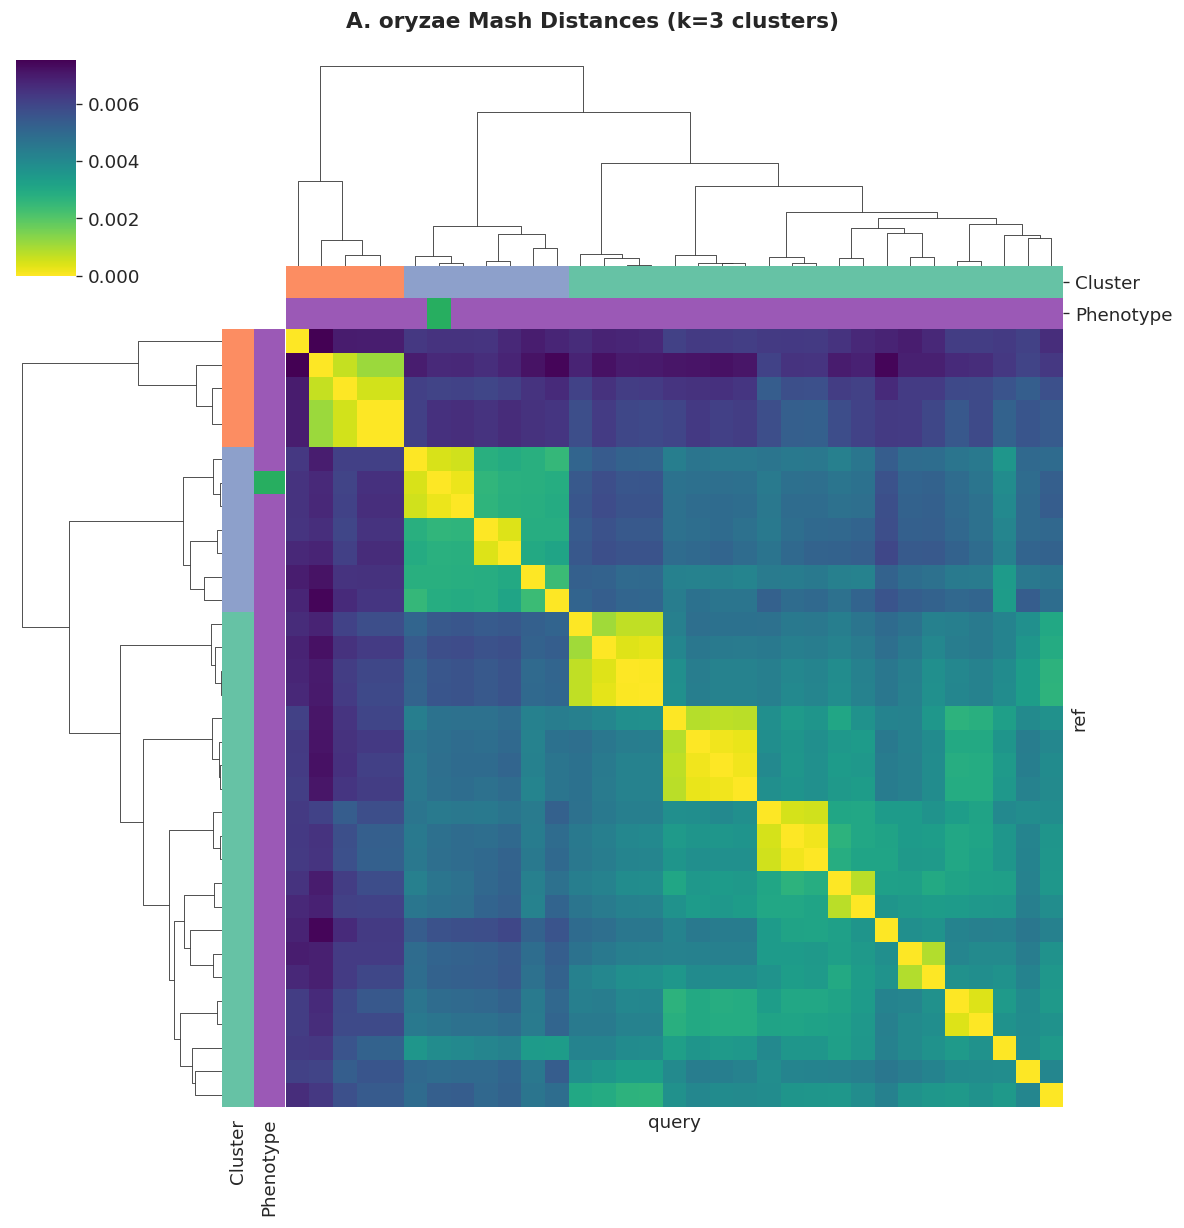

In [23]:
fphy.run_mash_kmeans(
    SPECIES_LIST_MASH, SPECIES_DISPLAY_MASH,
    mash_results, acc_to_phenotype, RESULTS_DIR
)

### 8.3 All-species clustering

- Ward-linkage heatmap of the pairwise Mash distances across all genomes
- Saved to `NB4_Results/mash_clustering/all_species/`

Total genomes across all species: 210
  Loading pre-computed Mash distances from /datadrive/Analysis/NB4_Results/mash_clustering/all_species/all_species_distances.tsv
Combined distance matrix: (210, 210)
Saved: /datadrive/Analysis/NB4_Results/mash_clustering/all_species/all_species_genome_metadata.csv


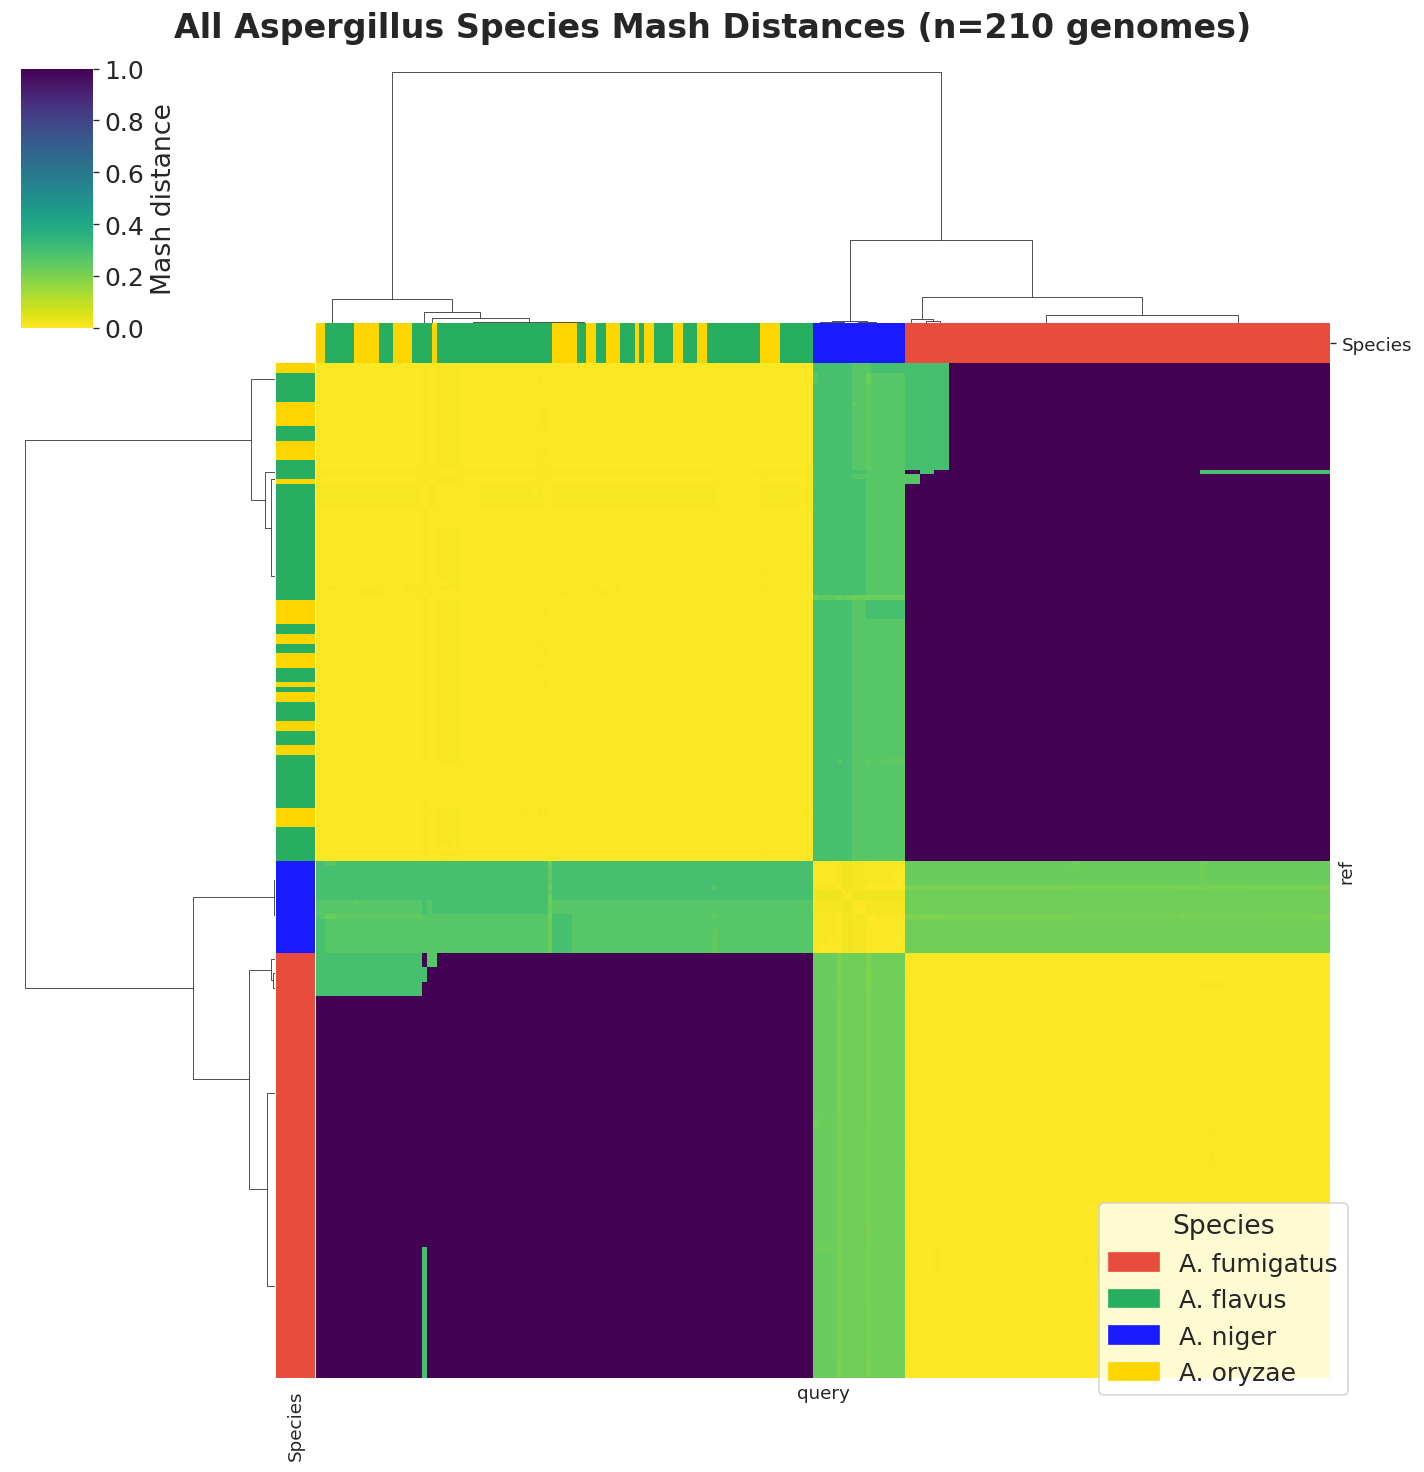

In [24]:
all_dist_matrix = fphy.run_mash_all_species(
    SPECIES_LIST_MASH, SPECIES_DISPLAY_MASH,
    GENUS, ANI_EXCLUDED, acc_to_phenotype, RESULTS_DIR
)

---
## Section 9: Kinship-corrected Burden Models

- Every model in this section uses the per-species kinship matrices from `NB1_Results/{species}/{species}_kinship.tsv`
- The response is `log1p(burden) - log(Mb)`, truly-rare orthogroups per Mb of assembly
- Between-species structure is carried by species fixed effects
- Requires the NB1 kinship and SNP PC tables

In [25]:
# Standalone bootstrap: run this cell to use Section 9 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

### 9.1 Pooled covariance matrices

- The four kinship matrices are scaled to mean diagonal 1 and assembled block-diagonally
- The combined species-tree covariance is built from the four-species OrthoFinder tree
- Saved to `NB4_Results/pooled_kinship_nb2.tsv` and `combined_tree_vcv.tsv`

In [26]:
covariances = fphy.build_pooled_covariances(
    NB1_RESULTS, NB4_RESULTS, SPECIES_TREE
)

Pooled covariance for the burden models = block-diagonal NB2 per-species kinship, 206 x 206
Saved -> /datadrive/Analysis/NB4_Results/pooled_kinship_nb2.tsv
Tree VCV (phylANOVA + diagnostic only) -> /datadrive/Analysis/NB4_Results/combined_tree_vcv.tsv

Within-species INDEPENDENT variation -- why the NB2 GRM is used to fit and the tree is not:
species          n                NB2 GRM    combined protein tree
  A. fumigatus     85                 101.1%                     1.6%
  A. flavus        69                 101.5%                     0.6%
  A. niger         19                 105.6%                     0.9%
  A. oryzae        33                 103.1%                     0.7%

The NB2 GRM retains essentially all within-species variation; the protein tree retains ~1%.
Between-species entries are 0 in the block-diagonal matrix by construction -- handled by
species fixed effects in every model, not by the covariance.


### 9.2 Correction for population structure

- Each contrast is fitted four ways: uncorrected, with the top 5 SNP principal components, with the kinship random effect, and with both
- `burden_h2` is the fraction of burden variance explained by kinship
- Saved to `NB4_Results/rare_burden_kinship_control.csv`

In [27]:
kinship_control = fphy.run_burden_kinship_control(NB1_RESULTS, NB4_RESULTS)

Does the truly-rare burden survive correction for phylogenetic relatedness?
(burden_h2 = fraction of burden variance explained by kinship;
 kinship_only = GRM random effect; kinship_plus_PC = GRM + top-5 SNP PCs as fixed covariates)

                                              contrast   n naive_p PC_only_p kinship_only_p kinship_plus_PC_p  burden_h2
               A. fumigatus | Human-pathogenic vs rest  85 9.7e-12   2.5e-10        3.9e-07           6.2e-11       0.64
                  A. flavus | Human-pathogenic vs rest  69 1.0e-02   1.1e-01        7.5e-02           2.3e-01       0.82
                   A. niger | Industrial-trait vs rest  19 1.8e-01   9.4e-01        1.6e-01           9.3e-01       0.00
fumigatus+flavus (combined) | Human-pathogenic vs rest 154 1.3e-14         -        6.6e-08           2.5e-07       0.69
    niger+oryzae (combined) | Industrial-trait vs rest  52 8.1e-03         -        1.5e-02           1.0e-01       0.00

Saved -> /datadrive/Analysis/NB4_Result

### 9.3 Four contrasts in two pairs

- Pair 1: phenotype against conspecifics, with a species fixed effect
- Pair 2: *A. oryzae* against *A. flavus*, without a species fixed effect
- Saved to `NB4_Results/burden_manuscript_four_panel.png` and `.csv`

Saved -> /datadrive/Analysis/NB4_Results/burden_manuscript_four_panel.png 

panel                                            contrast  n_case  n_rest mean_case mean_rest  fold        p                 covariance
    A Human-pathogenic vs Rest (A. fumigatus + A. flavus)      80      74      0.61      0.25 2.42x 7.38e-08   NB2 kinship + species FE
    B           Industrial vs Rest (A. niger + A. oryzae)      44       8      0.38      0.93 0.57x 1.19e-02   NB2 kinship + species FE
    C  A. oryzae Industrial vs A. flavus Human-pathogenic      32      43      0.27      0.59 0.54x 3.25e-06 NB2 kinship, no species FE
    D  A. oryzae Industrial vs A. flavus Plant-pathogenic      32      19      0.27      0.33 1.01x 9.69e-01 NB2 kinship, no species FE

Saved -> /datadrive/Analysis/NB4_Results/burden_manuscript_four_panel.csv


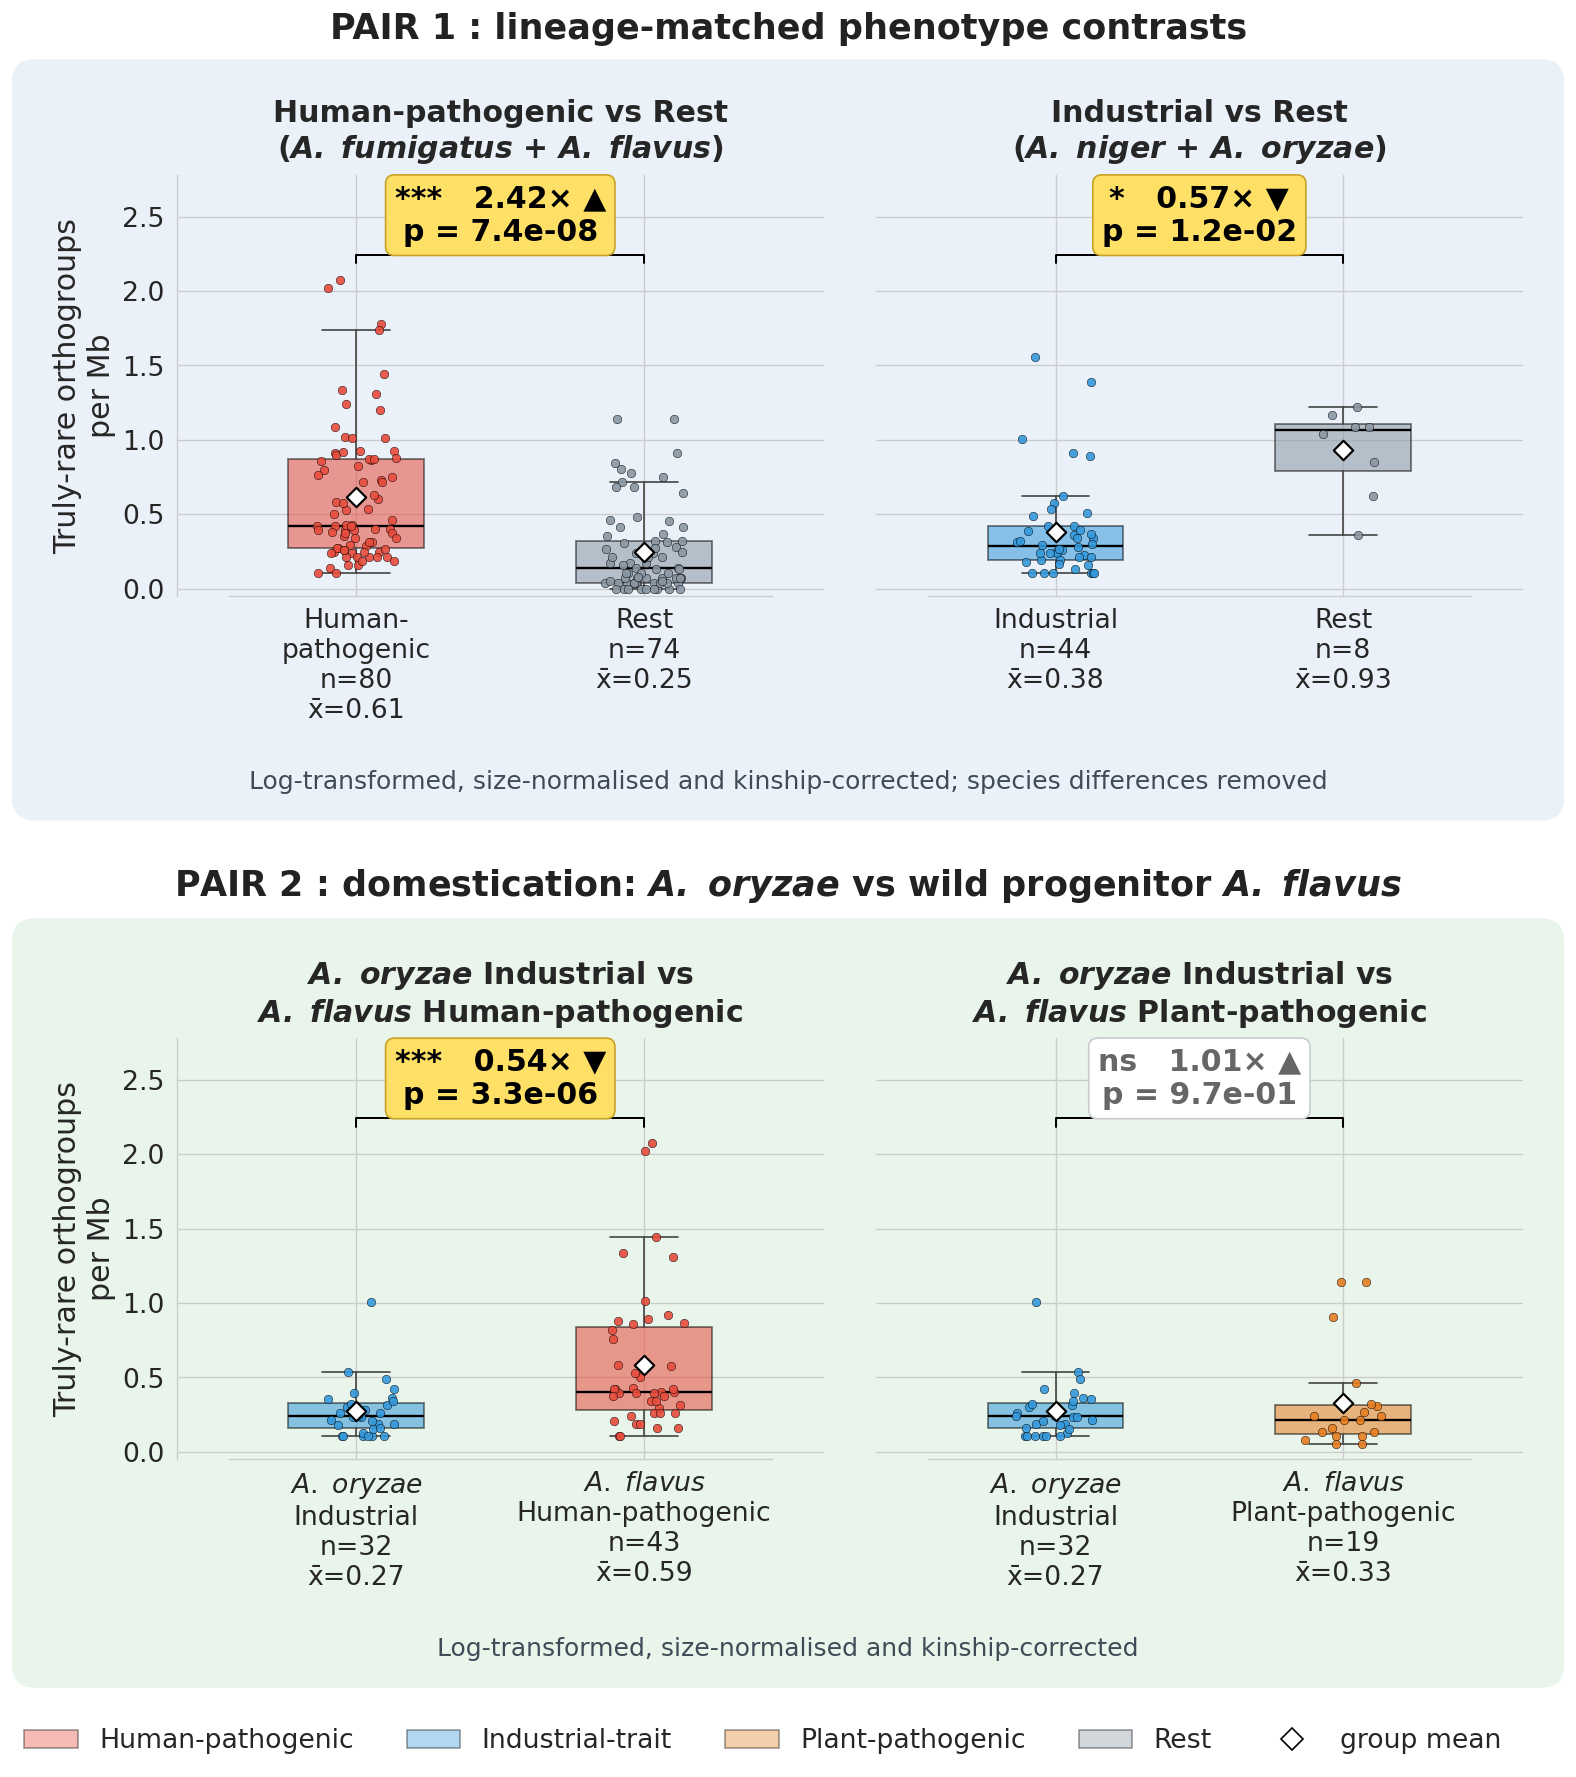

In [28]:
fig_four, four_panel = fphy.plot_burden_four_panel(
    NB1_RESULTS, NB4_RESULTS, QC_TABLE
)
plt.show()

---
## Section 10: Summary

- Rare and truly-rare orthogroup counts per species
- Every output file with its full path under `NB4_Results/`

In [29]:
# Standalone bootstrap: run this cell to use Section 10 from a fresh kernel.
import os, sys, warnings
from pathlib import Path

# --- Paths: edit these to point at your own data ---
FUNPAN_ROOT  = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'Analysis').is_dir() and (p / 'Code').is_dir())
ANALYSIS_DIR = FUNPAN_ROOT / 'Analysis'
SPECIES_DIR  = FUNPAN_ROOT / 'Species'
GENUS        = 'Aspergillus'

SPECIES_ROOT = SPECIES_DIR / GENUS
BASE_PATH    = str(SPECIES_ROOT)
NB0_RESULTS  = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS  = ANALYSIS_DIR / 'NB1_Results'
NB4_RESULTS  = ANALYSIS_DIR / 'NB4_Results'
RESULTS_DIR  = str(NB4_RESULTS)
QC_TABLE     = NB0_RESULTS / 'qc_passed_metadata_enriched.csv'
SPECIES_TREE = (SPECIES_ROOT / 'all_combined' / 'orthofinder_output' /
                'Results_Dec14' / 'Species_Tree' / 'SpeciesTree_rooted.txt')

sys.path.insert(0, str(ANALYSIS_DIR))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import funpan_utils as fpu
import funpan_phylo as fphy

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

SPECIES_LIST    = fpu.SPECIES_LIST
SPECIES_DISPLAY = fpu.SPECIES_DISPLAY
SPECIES_COLORS  = fpu.SPECIES_COLORS
ANI_EXCLUDED    = {
    'flavus':    {'GCA_023653635.1'},
    'fumigatus': {'GCA_049901915.1'},
}
SPECIES_CONFIG = {
    sp: {
        'label':             f'A. {sp}',
        'annot_path':        os.path.join(BASE_PATH, sp, f'{sp}_ortho_annot_long.tsv'),
        'pav_path':          os.path.join(NB1_RESULTS, sp, f'{sp}_pav.tsv'),
        'og_consensus_path': os.path.join(NB1_RESULTS, sp, f'{sp}_og_consensus.tsv'),
    }
    for sp in SPECIES_LIST
}

In [30]:
summary_counts, summary_files = fphy.print_nb4_summary(SPECIES_LIST, NB4_RESULTS)
display(summary_counts)

Rare-genome outputs under /datadrive/Analysis/NB4_Results
  present: 55/58
  OK /datadrive/Analysis/NB4_Results/rare_genome_summary.csv
  OK /datadrive/Analysis/NB4_Results/diamond_classification_pies.png
  OK /datadrive/Analysis/NB4_Results/rare_gene_burden_all_genomes.csv
  OK /datadrive/Analysis/NB4_Results/rare_gene_characterisation_summary.csv
  OK /datadrive/Analysis/NB4_Results/og_length_by_class.csv
  OK /datadrive/Analysis/NB4_Results/orf_completeness_by_class.csv
  OK /datadrive/Analysis/NB4_Results/compartment_length_pfam_orf.csv
  OK /datadrive/Analysis/NB4_Results/compartment_length_pfam_orf.png
  OK /datadrive/Analysis/NB4_Results/cog_enrichment_rare_vs_nonrare.csv
  OK /datadrive/Analysis/NB4_Results/rare_xenolog_ncbi_blast_results.tsv
  OK /datadrive/Analysis/NB4_Results/rare_xenolog_kingdom_summary.csv
  OK /datadrive/Analysis/NB4_Results/rare_xenolog_confident_hits.csv
  OK /datadrive/Analysis/NB4_Results/rare_xenolog_taxonomy.png
  OK /datadrive/Analysis/NB4_Results/

,Species,Rare OGs,Truly-rare (No hit),Paralog,Fragment,No significant similarity,% truly-rare
0,A. fumigatus,771,291,103,255,122,37.7
1,A. flavus,1159,391,158,400,210,33.7
2,A. niger,576,276,82,118,100,47.9
3,A. oryzae,552,156,76,226,94,28.3
